<a href="https://colab.research.google.com/github/data-188-berkeley/hw5/blob/main/hw5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW5: Vision Transformer and Masked Autoencoder

In this assignment, you will be implementing [Vision Transformer (ViT)](https://arxiv.org/abs/2010.11929) and [Masked Autoencoder (MAE)](https://arxiv.org/abs/2111.06377).

Notably, you will implement the following training strategies for CIFAR-10 image classification to validate the MAE pretraining methodology:
- (V1) "ViT only". Randomly initialize a ViT, and train on CIFAR-10.
- (V2) "ViT + MAE, linear probing". Pretrain a (randomly initialized) ViT via MAE approach. Then, finetune on CIFAR-10 via linear probing.
- (V3) "ViT + MAE, full finetuning". Just like (V2), but during CIFAR-10 finetuning, jointly train both the ViT and the linear classifier.


## Clarifications Doc

In case we need to give any clarifications (or hints!) for the assignment, see this Google Doc: ["HW5 Clarifications"](https://docs.google.com/document/d/1MdGQDIBSY3MUcSA8IFPRWKrmv50QL7TrceBnAOS4yPw/edit?tab=t.0).
This doc will be regularly updated.

## General Tips

Unless otherwise instructed, don't modify cells aside from in between the blocks with `# BEGIN YOUR SOLUTION`, `# END YOUR SOLUTION`.

Modifying other code can result in failing autograder tests.

**CPU vs GPU**: We recommend you to start work on this notebook using a CPU Colab instance at first.
Then, switch over to a GPU instance (T4) only when the instructions tell you to do so (namely, when it's time to train a larger-scale model).
This is to avoid running out of GPU compute, as Colab limits the amount of GPU hours you can use.

More details: for practical reasons (namely limited Colab GPU availability), our advice is to first complete this assignment in a CPU environment with small model sizes, then re-run the notebook in GPU mode with "full" model sizes".

To help you with this, in all Colab cells where you train ML models, we have provided two model settings: "ModelSize.FULL" and "ModelSize.TINY". We recommend first running "ModelSize.TINY" in a CPU runtime, and get your notebook to first successfully run end-to-end in a CPU environment. Note that, due to the smaller model sizes, you won't meet the validation accuracy checks.

Once you're convinced that your implementations are correct, then switch the model train mode to use larger model sizes (`MODEL_SIZE = ModelSize.FULL`), switch to the GPU environment, and run the entire notebook (eg "Runtime->Run All" or "Runtime->Run cell and below").

**Tip:** to further reduce time, we reduced the number of train epochs when training on CPU to 3 epochs, as this is enough for simple initial checks.
When training on the GPU, the notebook will auto-switch to a longer train schedule of 20 epochs, which should be enough epochs for you to achieve the target validation accuracy checks.

**Important**: to receive full credit on this homework (eg pass all autograder tests), you will need to submit a submission using the "ModelSize.FULL" model settings.

Note that this notebook is designed to work both in a CPU and GPU runtime.

To switch to a GPU runtime, click the dropdown menu right of the "Connect" button on the upper-right corner of the Colab UI, choose "Change runtime type", and choose "T4 GPU". This will connect you to an instance with an Nvidia GPU.

Here is a guide that shows how to change the Colab notebook runtime to the T4 GPU: [link](https://www.geeksforgeeks.org/how-to-use-gpu-in-google-colab/)

## Setup

Please run the below cell, which will download the assignment code to your Google Drive at: `My Drive/data188/hw5/`

Once the below cell completes, please exit this notebook window, and open up the notebook located at `My Drive/data188/hw5/hw5.ipynb`.
This is to ensure that your homework progress (code, generated figures) is saved to the correct location.

In [6]:
# Run this cell each time your kernel is disconnected or restarted
# Tip: it's always safe to re-run this, this will never delete data

import os
import sys

# basedir_course: All colab material for this course will live here.
#   Feel free to modify this if you'd like.
basedir_course = "/content/drive/MyDrive/data188"
# asn_name: name of assignment, eg hw4. This must match github repo name.
asn_name = "hw5"
rootdir_asn = os.path.join(basedir_course, asn_name)

# Fetch code to set up the assignment, then set the correct working directory
# (eg for python imports to work)
from google.colab import drive

drive.mount("/content/drive")

os.makedirs(basedir_course, exist_ok=True)
os.chdir(basedir_course)
os.system(f"git clone https://github.com/data-188-berkeley/{asn_name}.git")
os.chdir(rootdir_asn)

# install required libraries
!pip3 install einops

# Validate that our current working directory is correct.
# This should output:
#   /content/drive/MyDrive/data188/hw4/
print("Current working directory: ", os.getcwd())
# Another check: let's double check that the files in hw4/ are in the current directory.
# This should output something like:
#   ['.git', 'LICENSE', 'apps', 'data', 'hw4.ipynb', 'tests', '.pytest_cache']
print("ls cwd: ", os.listdir(os.getcwd()))

# ==== Important: modify path to allow our imports to work to work ====
# Implementation note: Annoyingly, we can't append to an existing env-var via
# ipython `set_env` like we can in bash (eg PYTHONPATH=new_path/:$PYTHONPATH).
# Instead we assume that PYTHONPATH starts as: /env/python, eg the below
# line is hopefully equivalent to:
#   PYTHONPATH=./python/:$PYTHONPATH
%set_env PYTHONPATH ./:/env/python
# We also need to modify sys.path directly so that the current python session
# can access our code
sys.path.insert(0, "./")

# outdir_base: where all generated data lives, including: datasets, tokenizers, and model snapshots
outdir_base = os.path.join(rootdir_asn, "./data/")
outdir_base_dataset = os.path.join(outdir_base, "datasets")
outdir_base_models = os.path.join(outdir_base, "model_snapshots")
os.makedirs(outdir_base_dataset, exist_ok=True)
os.makedirs(outdir_base_models, exist_ok=True)

print("Setup done!")

Mounted at /content/drive
Current working directory:  /content/drive/MyDrive/data188/hw5
ls cwd:  ['.git', '.gitattributes', '.gitignore', 'LICENSE', 'README.md', 'autograder_student.pt', 'hw5.ipynb', 'test_reference.pt', 'utils_public', 'data']
env: PYTHONPATH=./:/env/python
Setup done!


**Important:** At this point: please double check that you are working on the notebook located at `My Drive/data188/hw5/hw5.ipynb` before proceeding with the assignment!
Also: be sure that you regularly save your notebook, as you will be submitting this notebook (with output cells) as part of your submission!

### Set ModelSize

In [7]:
from enum import Enum


class ModelSize(str, Enum):
    # full: use the full-sized model architectures.
    #   Recommended to use this only for GPU runtimes.
    FULL = "full"
    # tiny: use tiny model architectures.
    #   Recommended for intial development in CPU runtimes.
    TINY = "tiny"


In [8]:
# IMPORTANT: this global var controls the model size to use for this notebook.
# Advice: for initial development, set this to ModelSize.TINY and use a CPU runtime.
#   Once you're able to run this notebook end-to-end on a CPU and things seem to work
#   (but with lower accuracy due to weaker model), try switching to a GPU runtime,
#   then switch to ModelSize.FULL.
MODEL_SIZE = ModelSize.TINY
print(f"Using MODEL_SIZE={MODEL_SIZE.value}")

Using MODEL_SIZE=tiny


In [9]:
import numpy as np

from matplotlib import pyplot as plt
from tqdm.notebook import trange, tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from collections import defaultdict
from typing import Any, Optional
import os

from utils_public.utils_torch import count_model_parameters
from utils_public.utils_torch import visualize_image_classifier_preds
from utils_public.utils_torch import visualize_mae_predictions
from utils_public.utils_torch import create_undo_img_standardization
from utils_public.utils_viz_metrics_hw5 import plot_train_val_metrics
from utils_public.utils_viz_metrics_hw5 import plot_train_val_metrics_cmp
from utils_public.utils_autograder import (
    save_student_data,
    check_error,
    check_acc,
)
from utils_public.utils_train_hw5 import load_if_exists_else_train

torch_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch_device={torch_device}")

if torch_device == "cuda":
    use_amp = True
    # torch.compile() can considerably improve training throughput
    # reduce-overhead: since our model+batchsize is fairly small, this is better
    # than 'default'
    torch_compile_mode = "reduce-overhead"
else:
    # cpu: disable amp and torch.compile()
    # As of 2026-04-24, it seems that torch.compile() on CPU has spotty support, and
    # can result in errors like: InductorError
    use_amp = False
    torch_compile_mode = None

torch_device=cpu


In [10]:
# Load testing data
test_data = torch.load("./test_reference.pt", weights_only=True)
auto_grader_data = torch.load("./autograder_student.pt", weights_only=True)

# ================================================================
# Code for managing student data (for autograder)
# ================================================================
OUTPATH_STUDENT_DATA = os.path.join(rootdir_asn, "student_data.pt")

# Initialize important data structures.
# submission dict, with keys:
#   ["output"][str name] -> data_to_check
student_data: dict[str, dict[str, Any]] = defaultdict(dict)

## Vision Transformer
The first part of this notebook is implementing Vision Transformer (ViT) and training it on CIFAR dataset.

To learn more about the ViT approach, please read the original ViT paper: ["An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"](https://arxiv.org/abs/2010.11929).

### Image patchify and unpatchify

In ViT, an image is split into fixed-size patches, each of them are then linearly embedded, position embeddings are added, and the resulting sequence of vectors is fed to a standard Transformer encoder. The architecture can be seen in the following figure.
![vit](https://github.com/google-research/vision_transformer/blob/main/vit_figure.png?raw=true)

To get started with implementing ViT, you need to implement splitting image batch into fixed-size patches batch in ```patchify``` and combining patches batch into the original image batch in ```unpatchify```.

We strongly recommend using [einops](https://github.com/arogozhnikov/einops) for flexible tensor operations, you can check out its [tutorial](https://einops.rocks/1-einops-basics/).

In [16]:
from einops import rearrange


def patchify(images: torch.Tensor, patch_size: int = 4) -> torch.Tensor:
    """Splits images into patches.
    Args:
        images: Input tensor with size (batch, channels, height, width)
            We can assume that image is square where height == width.
    Returns:
        image_patches: shape=[batch, num_patches, patch_pixels]
            where:
            num_patches = (height / patch_size) * (width / patch_size)
            patch_pixels = channels * patch_size * patch_size
    """
    batch, channels, height, width = images.shape
    assert height == width, f"Image height {height} should be equal to width {width}"
    assert height % patch_size == 0, (
        f"Image height {height} must be divisible by patch size {patch_size}"
    )
    assert width % patch_size == 0, (
        f"Image width {width} must be divisible by patch size {patch_size}"
    )
    # BEGIN YOUR SOLUTION
    # Hint: can be implemented in 1 line, use einops rearrange (https://einops.rocks/api/rearrange/)
    #   patches = rearrange(images, "b c (h hp) (w wp) -> b [FILL ME IN]", hp=patch_size, wp=patch_size)
    patches = rearrange(images, "b c (h hp) (w wp) -> b (h w) (c hp wp)",
                    hp=patch_size, wp=patch_size)
    # END YOUR SOLUTION

    # Quick shape check
    expected_shape = (
        batch,
        (height // patch_size) * (width // patch_size),
        channels * patch_size * patch_size,
    )
    assert patches.shape == expected_shape, (
        f"Expected patches.shape to be {expected_shape}, was: {patches.shape}"
    )
    return patches


def unpatchify(patches: torch.Tensor, patch_size: int = 4) -> torch.Tensor:
    """Rearrange patches back into images.
    The inverse of patchify().
    Args:
        patches: Input tensor with shape=[batch, num_patches, patch_pixels].
            The output of patchify().
        patch_size: The patch size.
    Returns:
        A batch of images with size (batch, channels, height, width)
    """
    batch, num_patches, patch_dim = patches.shape
    channels = patch_dim // (patch_size * patch_size)
    height = width = int((num_patches**0.5) * patch_size)

    # BEGIN YOUR SOLUTION
    # Hint: can be implemented in 1 line, use einops rearrange (https://einops.rocks/api/rearrange/)
    #   images = rearrange(patches, "[FILL ME IN] -> b c (h hp) (w wp)", h=height // patch_size, w=width // patch_size, hp=patch_size, wp=patch_size)
    images = rearrange(patches, "b (h w) (c hp wp) -> b c (h hp) (w wp)",
                   h=height // patch_size, w=width // patch_size,
                   hp=patch_size, wp=patch_size)
    # END YOUR SOLUTION

    expected_shape = (batch, channels, height, width)
    assert images.shape == expected_shape, (
        f"Expected images.shape={expected_shape}, was: {images.shape}"
    )
    return images


In [17]:
x = test_data["input"]["patchify"]
y = test_data["output"]["patchify"]
check_error("patchify", patchify(x), y)

x = auto_grader_data["input"]["patchify"]
student_data["output"]["patchify"] = patchify(x)

x = test_data["input"]["unpatchify"]
y = test_data["output"]["unpatchify"]
check_error("unpatchify", unpatchify(x), y)

x = auto_grader_data["input"]["unpatchify"]
student_data["output"]["unpatchify"] = unpatchify(x)

save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)

The relative error for patchify is 0.0
The relative error for unpatchify is 0.0
Wrote student data (with keys=dict_keys(['output'])) to: /content/drive/MyDrive/data188/hw5/student_data.pt
keys in 'output': dict_keys(['patchify', 'unpatchify'])


### ViT model

You need to use the given Transformer encoder ```Transformer``` to implement ViT in ```ViT``` and ```ClassificationViT```.

Our implementation differs from the original in that we use **Attention Pooling** instead of a dedicated classifier token `[CLS]`. What it does is aggregate the encoder output tokens (and the `[CLS]` token embedding) via a learned aggregation.

This learned aggregation is a cross attention layer, where the query sequence is the `[CLS]` token embedding (ie a sequence of length 1, repeated along batch dimension), and the key+value sequence is the encoder outputs.

The cross attention layer produces a single token embedding: this is the final summary embedding that we then pass to the downstream image classifier.

Note that we don't prepend the input sequence with the `[CLS]` token embedding: the `[CLS]` token embedding is only used during the cross-attention aggregation.

In [18]:
class Transformer(nn.Module):
    """Transformer Encoder"""

    def __init__(
        self,
        embedding_dim: int = 256,
        n_heads: int = 4,
        n_layers: int = 4,
        feedforward_dim: int = 1024,
    ):
        """
        Args:
            embedding_dim: dimension of embedding
            n_heads: number of attention heads
            n_layers: number of attention layers
            feedforward_dim: hidden dimension of MLP layer
        """
        super().__init__()
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.feedforward_dim = feedforward_dim
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=embedding_dim,
                nhead=self.n_heads,
                dim_feedforward=self.feedforward_dim,
                activation=F.gelu,
                batch_first=True,
                dropout=0.0,
            ),
            num_layers=n_layers,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: input. Shape=[batch, num_tokens, d].
        Returns:
            output_token_embeddings. shape=[batch, num_tokens, d]
        """
        return self.transformer(x)


class ClassificationViT(nn.Module):
    """Vision transformer for classfication"""

    def __init__(
        self,
        n_classes: int,
        embedding_dim: int = 256,
        patch_size: int = 4,
        num_patches: int = 8,
        num_channels: int = 3,
        n_layers: int = 4,
        feedforward_dim: int = 1024,
    ):
        """
        Args:
            n_classes: number of classes
            embedding_dim: dimension of embedding
            patch_size: side length of a square-shaped image patch
            num_patches: number of image patches per height/width
        """
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.embedding_dim = embedding_dim
        self.num_channels = num_channels
        self.n_layers = n_layers
        self.feedforward_dim = feedforward_dim
        self.n_classes = n_classes
        self.n_tokens = num_patches**2

        self.transformer = Transformer(
            embedding_dim, n_layers=n_layers, feedforward_dim=feedforward_dim
        )
        # We use learned position encoding.
        # You are welcome to try other methods, such as sinusoidal encoding.
        self.position_encoding = nn.Parameter(
            torch.randn(1, self.n_tokens, embedding_dim) * 0.02
        )
        self.patch_projection = nn.Linear((patch_size**2) * num_channels, embedding_dim)

        # Attention Pooling for classification
        # Aggregate encooder outputs (and cls_query) to produce "final" summarized embedding, via
        # cross attention aggregation, where:
        #   query is cls_query
        #   key, value is encoder outputs
        self.cls_query = nn.Parameter(torch.randn(1, 1, embedding_dim))
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=self.transformer.n_heads,
            batch_first=True,
        )

        # A Layernorm and a Linear layer are applied on ViT encoder embeddings
        self.output_head = nn.Sequential(
            nn.LayerNorm(embedding_dim), nn.Linear(embedding_dim, n_classes)
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """
        (1) Splitting images into fixed-size patches, dividing both height and width by patch size;
        (2) Linearly embed each image patch;
        (3) Add position embeddings;
        (4) Feed the resulting sequence of vectors to Transformer encoder.
        (5) Perform Attention Pooling. This is a learned aggregation of both the CLS
            token as well as the encoder output embeddings.
        (6) Apply output head to the embeddings to obtain the logits

        Args:
            images: (batch_size, channels, height, width)
        Returns:
            logits: shape=[batch_size, num_classes]
        """
        batch_size, channels, height, width = images.shape
        assert channels == self.num_channels, (
            f"Number of channels {channels} in the input image must be {self.num_channels}"
        )
        assert height == width, f"Input image {height}x{width} is not square"
        assert height == self.patch_size * self.num_patches, (
            f"Image height {height} doesn't match patch_size {self.patch_size} * num_patches {self.num_patches}"
        )
        token_count = self.num_patches * self.num_patches

        # BEGIN YOUR SOLUTION

        # (1) Split images into patches using patchify, can be implemented in 1 line

        # (2) Linearly embed each patch, can be implemented in 1 line

        # (3) Add position embeddings to the embedded patch in step (2), can be implemented in 1 line

        # (4) Feed the resulting sequence of vectors to Transformer encoder, can be implemented in 1 line
        # Note: you do not need to prepend the `cls_query` token to the input sequence here.

        # (5) Apply Attention Pooling, which applies self.cross_attention
        # on cls_query (query) and encoder output (key, value) from (4)
        # Can be implemented in < 5 lines
        # Hint: to repeat `cls_query` along batch dimension, do:
        #     # before expand: self.cls_query.shape=[1, 1, d]
        #     # after expand: cls_query_expand.shape=[batchsize, 1, d]
        #     cls_query_expand = self.cls_query.expand(batch_size, -1, -1)

        # (6) Apply output head to the output to obtain the logits, can be implemented in 1 line
        patches = patchify(images, patch_size=self.patch_size)

        assert patches.shape[1] == token_count

        patch_embeddings = self.patch_projection(patches)

        patch_embeddings = patch_embeddings + self.position_encoding

        encoder_outputs = self.transformer(patch_embeddings)

        cls_query_expand = self.cls_query.expand(batch_size, -1, -1)

        pooled_output, _ = self.cross_attention(
            query=cls_query_expand,
            key=encoder_outputs,
            value=encoder_outputs,
        )

        pooled_output = pooled_output.squeeze(1)

        logits = self.output_head(pooled_output)
        # END YOUR SOLUTION

        logits_expected_shape = (images.shape[0], self.n_classes)
        assert logits.shape == logits_expected_shape, (
            f"Expected logits.shape={logits_expected_shape}, was: {logits.shape}"
        )
        return logits


In [19]:
model = ClassificationViT(10)
model.load_state_dict(test_data["weights"]["ClassificationViT"])
x = test_data["input"]["ClassificationViT.forward"]
y = model.forward(x)
check_error(
    "ClassificationViT.forward", y, test_data["output"]["ClassificationViT.forward"]
)

model.load_state_dict(auto_grader_data["weights"]["ClassificationViT"])
x = auto_grader_data["input"]["ClassificationViT.forward"]
y = model.forward(x)
student_data["output"]["ClassificationViT.forward"] = y

save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)

The relative error for ClassificationViT.forward is 6.505370038212277e-07
Wrote student data (with keys=dict_keys(['output'])) to: /content/drive/MyDrive/data188/hw5/student_data.pt
keys in 'output': dict_keys(['patchify', 'unpatchify', 'ClassificationViT.forward'])


### Data Loader and Preprocess

We use ```torchvision``` to download and prepare images and labels.

In [20]:
CIFAR10_IMG_SHAPE = (3, 32, 32)
CIFAR10_IMG_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_IMG_STD = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.Resize(32),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_IMG_MEAN, CIFAR10_IMG_STD),
    ]
)

transform_test = transforms.Compose(
    [
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_IMG_MEAN, CIFAR10_IMG_STD),
    ]
)

batch_size = 128

trainset = torchvision.datasets.CIFAR10(
    root=outdir_base_dataset, train=True, download=True, transform=transform_train
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    # Important: for performance reasons, we drop the last batch to avoid
    # passing different-shaped batches to CUDA ops.
    drop_last=True,
    # Performance tuning
    prefetch_factor=4,
    # pin_memory only makes sense for cuda
    pin_memory=True if torch_device == "cuda" else False,
    persistent_workers=True,
)

testset = torchvision.datasets.CIFAR10(
    root=outdir_base_dataset, train=False, download=True, transform=transform_test
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    # Performance tuning
    prefetch_factor=4,
    # pin_memory only makes sense for cuda
    pin_memory=True if torch_device == "cuda" else False,
    persistent_workers=True,
)

# For visualization convenience, we'll also create a testloader_viz that doesn't
# apply image preprocessing (like mean/std standardization)
transform_test_viz = transforms.Compose(
    [
        transforms.Resize(32),
        transforms.ToTensor(),
    ]
)
testset_viz = torchvision.datasets.CIFAR10(
    root=outdir_base_dataset,
    train=False,
    download=True,
    transform=transform_test_viz,
)
testloader_viz = torch.utils.data.DataLoader(
    testset_viz,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
)

100%|██████████| 170M/170M [00:01<00:00, 92.1MB/s]


### [train] (V1) Supervised Training ViT

You are required to reach at least 65% validation accuracy (though you should be able to achieve quite a bit higher than that).

Here is a reference table to let you know roughly how your model should be performing:

| Model Size | Num Model Parameters | Train Loss | Train Accuracy | Val Accuracy | Per-epoch secs (CPU)* | Per-epoch secs (GPU)** |
| ---------- | ---- | ---------- | -------------- | ------------ | -------------------- | -------------------- |
| TINY (3 epochs)  | 730 | 2.10  | 0.2  | 0.2  | 38                  | 21                 |
| FULL (20 epochs)  | 3454474 | 0.4 - 0.45  | 0.8 - 0.85    | 0.75 - 0.79 | 1320                 | 25                   |

\* As measured on the default Google Colab CPU instance.

\** As measured on a Google Colab T4 GPU instance.

Note: With an Nvidia RTX 3080 GPU, I got 7 secs per epoch for model_size=FULL.

**Tip**: once you've successfully trained the model, it will be saved to disk at `./data/model_snapshots/`.
When you re-run this cell, this will load the model snapshot from disk, rather than training a new model, which will save you some time if you need to resume work on this notebook.

If you wish to retrain a model, either delete the model snapshot from disk, or set `force_retrain = True` in `train_loop()`.

In [21]:
# Initialize model (ClassificationViT)
# GPU(full): 6 mins (~30 secs per epoch)
# CPU(full): 220 mins (~22 mins per epoch))
# CPU(tiny): 10 mins (~1 min per epoch)
print(f"Creating ClassificationViT with MODEL_SIZE={MODEL_SIZE}")
if MODEL_SIZE == ModelSize.FULL:
    model = ClassificationViT(10)
else:
    # TINY
    model = ClassificationViT(10, embedding_dim=4, n_layers=1, feedforward_dim=4)

model = model.to(device=torch_device)
if torch_compile_mode is not None:
    model = torch.compile(model, mode=torch_compile_mode)

print(f"Num model parameters (unfrozen): {count_model_parameters(model)}")
print(
    f"Num model parameters (frozen+unfrozen): {count_model_parameters(model, only_trainable=False)}"
)

# Create optimizer for the model

# Tip: with a correct implementation (and "full" model size), you should be able to pass
#   the autograder tests with these provided hyperparameter values.
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.95),
    weight_decay=1e-2,
    eps=1e-9,
)
if use_amp:
    grad_scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
else:
    grad_scaler = None

if torch_device == "cpu":
    # CPU is only for small-scale testing, no need to train many epochs
    num_epochs = 3
else:
    # GPU: full epoch train schedule
    num_epochs = 20

outpath_vit_only_best = os.path.join(
    outdir_base_models, f"v1_vit_supervised_best_{MODEL_SIZE.value}.pth"
)
outpath_vit_only_best_meta = f"{outpath_vit_only_best}.meta"

train_meta, val_meta = load_if_exists_else_train(
    model=model,
    optimizer=optimizer,
    dataloader_train=trainloader,
    dataloader_val=testloader,
    num_epochs=num_epochs,
    outpath_best_val=outpath_vit_only_best,
    outpath_best_val_meta=outpath_vit_only_best_meta,
    is_jupyter_notebook=True,
    # set force_retrain to True to retrain model even if it already exists on disk
    force_retrain=False,
    use_amp=use_amp,
    grad_scaler=grad_scaler,
)


Creating ClassificationViT with MODEL_SIZE=ModelSize.TINY
Num model parameters (unfrozen): 730
Num model parameters (frozen+unfrozen): 730


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=1/3] (Train) dur=33.97s. tput=1471.89 exs/s (Val) dur=3.74s tput=2673.78 exs/s. val_acc=0.196796 (best_val_acc=0.000000)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v1_vit_supervised_best_tiny.pth (val_acc=0.196796 vs prev_best_val_acc=0.196796) (flip_val_acc_cmp=False)


  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=2/3] (Train) dur=33.39s. tput=1497.53 exs/s (Val) dur=5.31s tput=1881.75 exs/s. val_acc=0.207971 (best_val_acc=0.196796)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v1_vit_supervised_best_tiny.pth (val_acc=0.207971 vs prev_best_val_acc=0.207971) (flip_val_acc_cmp=False)


  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=3/3] (Train) dur=34.13s. tput=1465.15 exs/s (Val) dur=3.21s tput=3111.88 exs/s. val_acc=0.226365 (best_val_acc=0.207971)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v1_vit_supervised_best_tiny.pth (val_acc=0.226365 vs prev_best_val_acc=0.226365) (flip_val_acc_cmp=False)
Training complete. 113.87 secs. best_val_acc=0.226365
Saved train/val meta to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v1_vit_supervised_best_tiny.pth.meta


#### Visualize predictions (V1)

Running inference on 10000 samples...
Finished inference on 10000 samples (4.66 secs, throughput=2143.96 samples/sec)
uhoh, not enough, skipping: (0, 32, 32, 3), 0
uhoh, not enough, skipping: (0, 32, 32, 3), 0


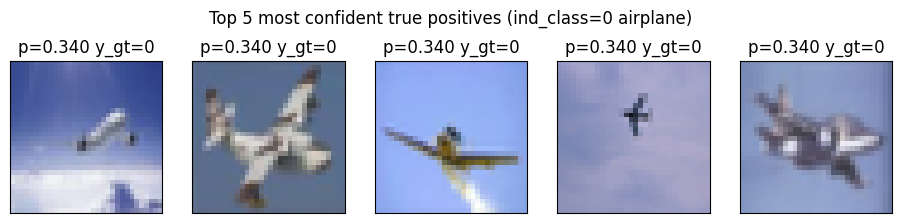

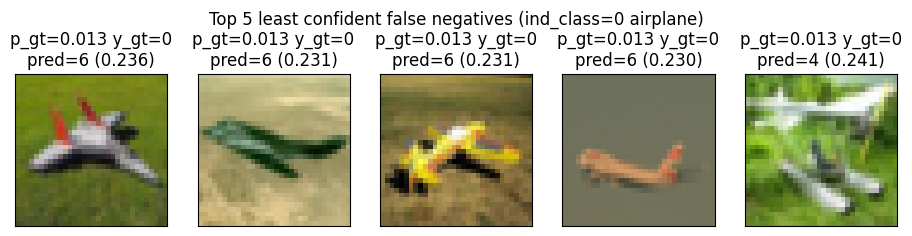

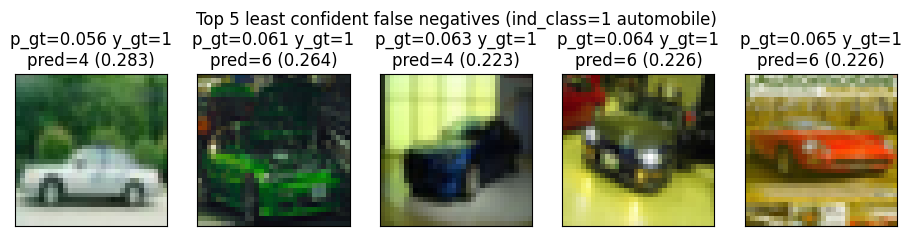

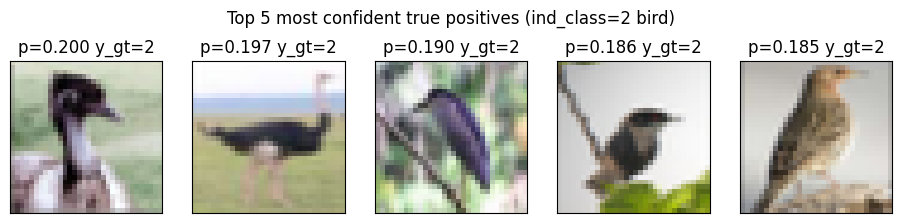

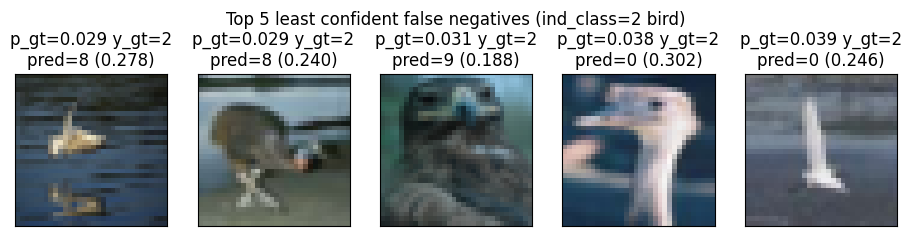

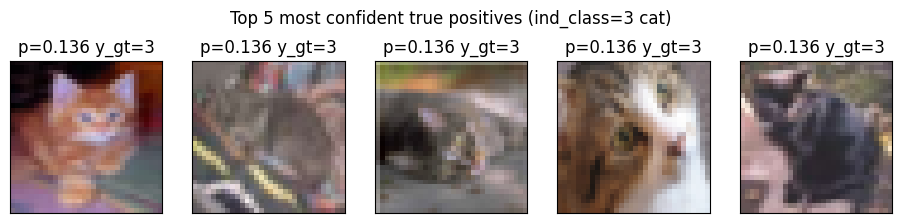

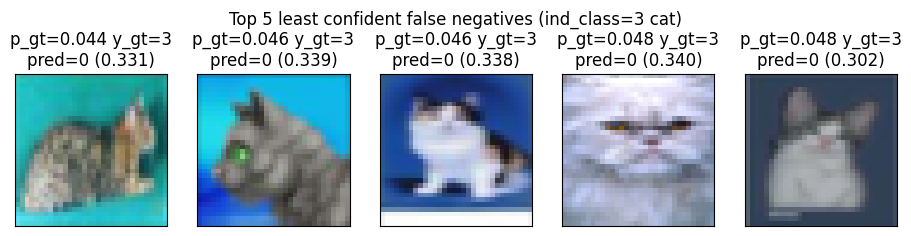

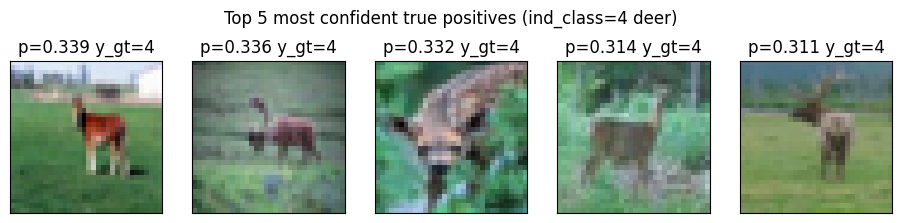

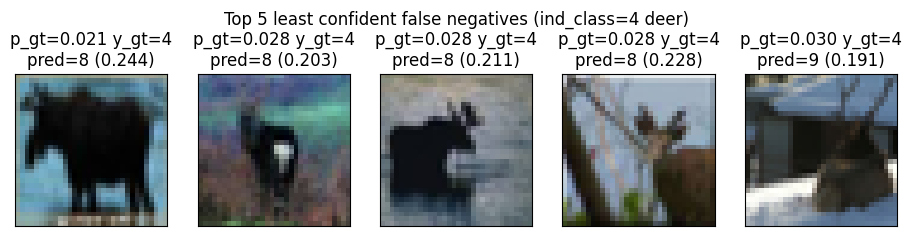

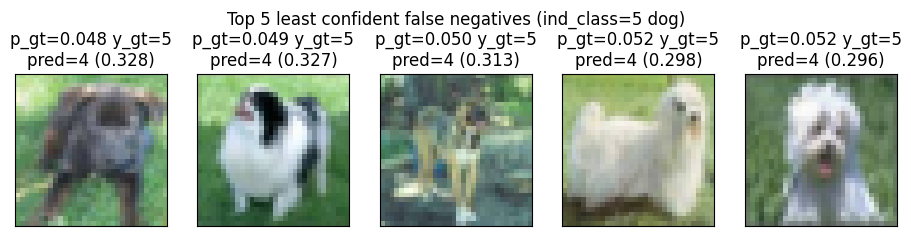

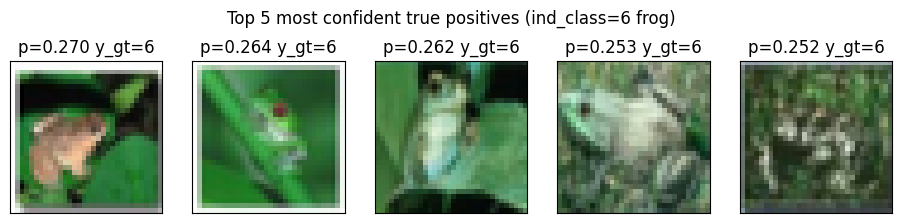

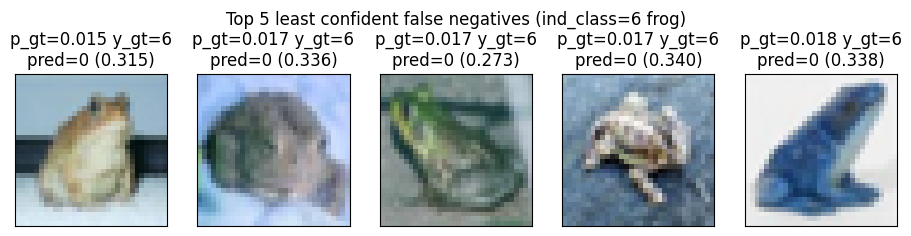

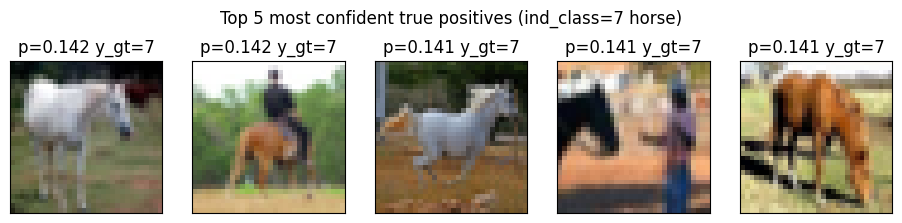

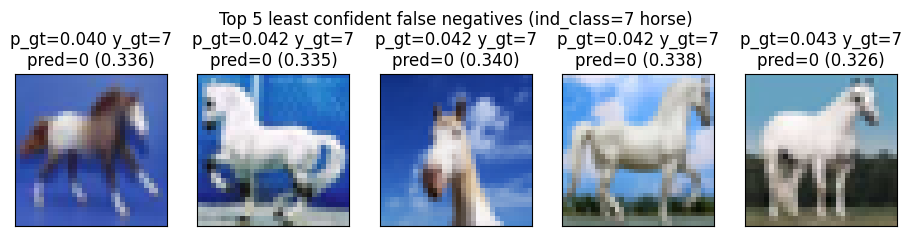

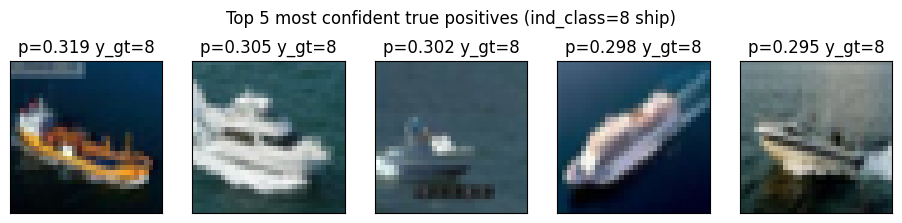

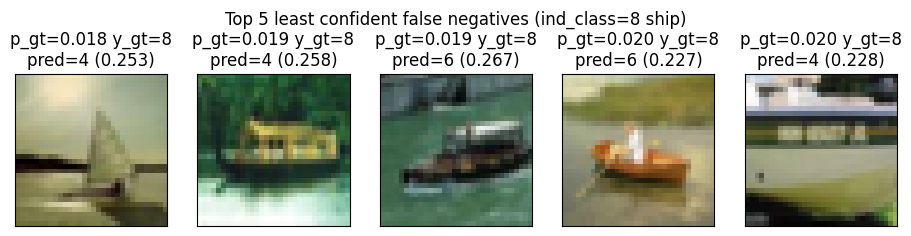

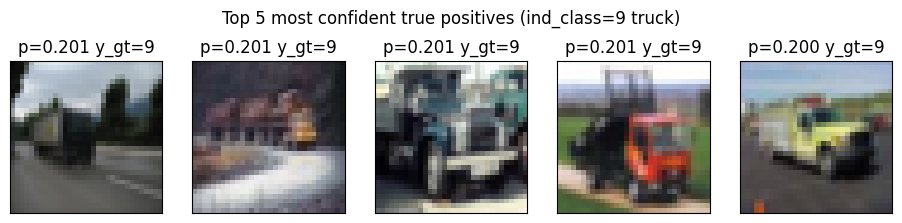

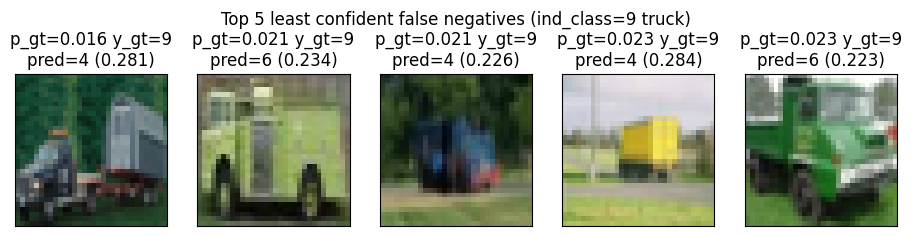

In [22]:
visualize_image_classifier_preds(
    model=model,
    dataloader=testloader,
    class_names=testloader.dataset.classes,
    image_shape=(3, 32, 32),
    top_k=5,
    dataloader_viz=testloader_viz,
)

#### Visualize metrics (V1)

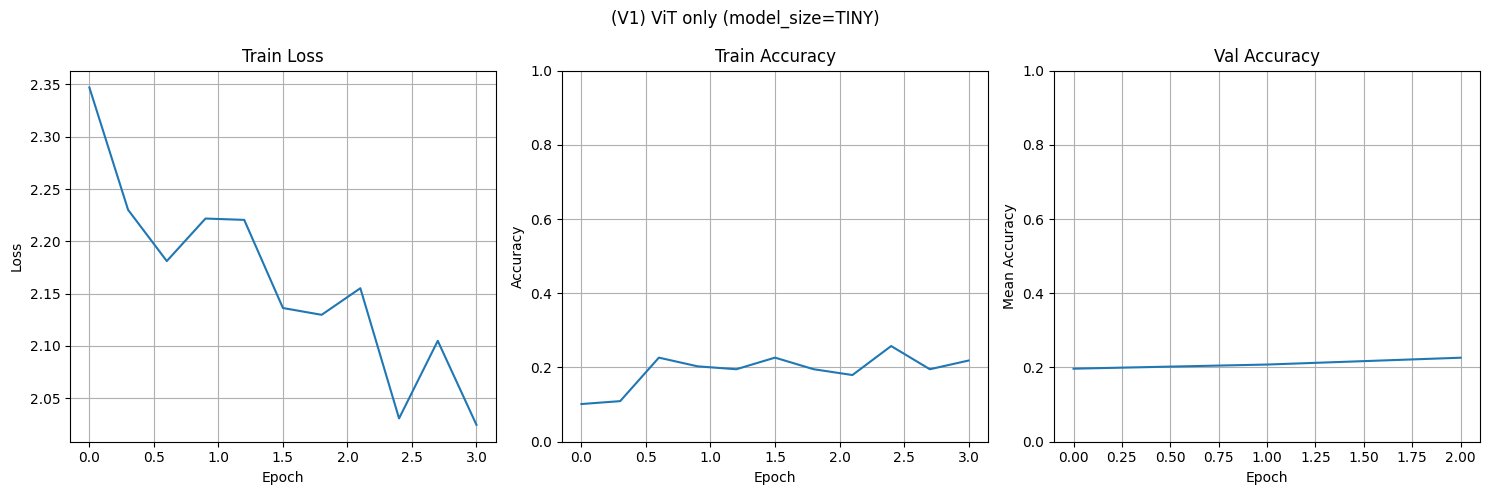

In [23]:
# Plotting
suptitle = f"(V1) ViT only (model_size={MODEL_SIZE.name})"

fig = plot_train_val_metrics(
    train_meta=train_meta,
    val_meta=val_meta,
    suptitle=suptitle,
)

fig.tight_layout()
fig.show()

In [24]:
# Your val accuracy should be greater than 65%
best_val_acc = np.max(val_meta["accuracy_per_epoch"]).item()
student_data["output"]["vit_acc"] = best_val_acc

save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)
check_acc(best_val_acc, threshold=0.65)

Wrote student data (with keys=dict_keys(['output'])) to: /content/drive/MyDrive/data188/hw5/student_data.pt
keys in 'output': dict_keys(['patchify', 'unpatchify', 'ClassificationViT.forward', 'vit_acc'])
The accuracy 0.22636471518987342 should >= threshold accuracy 0.65


## Masked AutoEncoder

The second part of this notebook is implementing [Masked Autoencoder (MAE)](https://en.wikipedia.org/wiki/Masked_autoencoder).
The idea of MAE is masking random patches of the input image and reconstruct the missing pixels. This whole achitecture can be seen in the following figure.
![mae](https://user-images.githubusercontent.com/11435359/146857310-f258c86c-fde6-48e8-9cee-badd2b21bd2c.png)

You will train MAE without labels on CIFAR, aka, self-supervised learning.
Then you will use the self-supervised pretrained model for linear classification and finetuning experiments.

To learn more details about the MAE approach, please read the original MAE paper: ["Masked Autoencoders Are Scalable Vision Learners"](https://arxiv.org/abs/2111.06377).

In [25]:
def index_sequence(x: torch.Tensor, ids: torch.Tensor) -> torch.Tensor:
    """Index tensor (x) with indices given by ids
    Args:
        x: input sequence tensor, can be 2D (batch x length) or 3D (batch x length x feature)
        ids: 2D indices (batch x length) for re-indexing the sequence tensor
    Returns:
        result: a tensor with the same shape as x, but permuted on the "length" dimension according to ids.
    """
    batch, length = ids.shape

    assert len(x.shape) in [2, 3], (
        f"Input tensor x should have 2 or 3 dimensions, but has shape {x.shape}"
    )
    if len(x.shape) == 3:
        ids = ids.unsqueeze(-1).expand(-1, -1, x.shape[-1])
    result = torch.take_along_dim(x, ids, dim=1)
    assert result.shape == x.shape
    return result


def random_masking(
    x: torch.Tensor, keep_length: int, ids_shuffle: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Apply random masking on input tensor
    Args:
        x:  (batch, length, feature) input patches
        keep_length: int, length of unmasked patches
        ids_shuffle: (batch, length) random indices for shuffling the input sequence
    Returns:
        kept: (batch, keep_length, feature) un-masked part of x
        mask: (batch, length) a 2D (batch x length) mask tensor of 0s and 1s indicated which
            part of x is masked out. The value 0 indicates not masked and 1
            indicates masked.
        ids_restore: (batch, length) indices to restore x. If we take the kept part and masked
            part of x, concatentate them together and index it with ids_restore,
            we should get x back.

    Hint:
        ids_shuffle contains the indices used to shuffle the sequence (patches).
        You should use the provided index_sequence function to re-index the
        sequence, and keep the first keep_length number of patches.
    """
    batch, length, feature = x.shape
    # BEGIN YOUR SOLUTION


    x_shuffled = index_sequence(x, ids_shuffle)

    kept = x_shuffled[:, :keep_length, :]

    ids_restore = torch.argsort(ids_shuffle, dim=1)

    mask = torch.ones((batch, length), device=x.device)
    mask[:, :keep_length] = 0
    mask = index_sequence(mask, ids_restore)
    # END YOUR SOLUTION

    # Shape checks
    kept_expected_shape = (batch, keep_length, feature)
    assert kept.shape == kept_expected_shape, (
        f"Expected kept.shape={kept_expected_shape}, was: {kept.shape}"
    )

    ids_restore_expected_shape = (batch, length)
    assert ids_restore.shape == ids_restore_expected_shape, (
        f"Expected ids_restore.shape={ids_restore_expected_shape}, was: {ids_restore.shape}"
    )

    mask_expected_shape = (batch, length)
    assert mask.shape == mask_expected_shape, (
        f"Expected mask.shape={mask_expected_shape}, was: {mask.shape}"
    )

    return kept, mask, ids_restore


def restore_masked(
    kept_x: torch.Tensor, masked_x: torch.Tensor, ids_restore: torch.Tensor
) -> torch.Tensor:
    """Restore masked patches.
    Inverse of random_masking().
    Args:
        kept_x: unmasked patches, (batch x keep_length x feature)
        masked_x: masked patches, (batch x mask_length x feature)
        ids_restore: indices to restore x, (batch x length)
    Returns:
        restored: restored patches, (batch x length x feature)
    """
    # BEGIN YOUR SOLUTION

   # BEGIN YOUR SOLUTION

    # (1) Concatenate kept and masked patches
    x_combined = torch.cat([kept_x, masked_x], dim=1)

    # (2) Restore the original order
    restored = index_sequence(x_combined, ids_restore)

# END YOUR SOLUTION
    # END YOUR SOLUTION

    return restored

### Random Masking and Restore

To get started with MAE, you need to implement ```random_masking``` to mask random patches from the input image and ```restore_masked``` to combine reconstructed masked part and unmasked part to restore the image.

In [26]:
# Test your implementation
x, ids_shuffle = test_data["input"]["random_masking"]
kept, mask, ids_restore = random_masking(x, 4, ids_shuffle)
kept_t, mask_t, ids_restore_t = test_data["output"]["random_masking"]
check_error("random_masking: kept", kept, kept_t)
check_error("random_masking: mask", mask, mask_t)
check_error("random_masking: ids_restore", ids_restore, ids_restore_t)

x, ids_shuffle = auto_grader_data["input"]["random_masking"]
kept, mask, ids_restore = random_masking(x, 4, ids_shuffle)
student_data["output"]["random_masking"] = (kept, mask, ids_restore)
save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)

kept_x, masked_x, ids_restore = test_data["input"]["restore_masked"]
restored = restore_masked(kept_x, masked_x, ids_restore)
check_error("restore_masked", restored, test_data["output"]["restore_masked"])

kept_x, masked_x, ids_restore = auto_grader_data["input"]["restore_masked"]
restored = restore_masked(kept_x, masked_x, ids_restore)
student_data["output"]["restore_masked"] = restored
save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)

The relative error for random_masking: kept is 0.0
The relative error for random_masking: mask is 0.0
The relative error for random_masking: ids_restore is 0.0
Wrote student data (with keys=dict_keys(['output'])) to: /content/drive/MyDrive/data188/hw5/student_data.pt
keys in 'output': dict_keys(['patchify', 'unpatchify', 'ClassificationViT.forward', 'vit_acc', 'random_masking'])
The relative error for restore_masked is 0.0
Wrote student data (with keys=dict_keys(['output'])) to: /content/drive/MyDrive/data188/hw5/student_data.pt
keys in 'output': dict_keys(['patchify', 'unpatchify', 'ClassificationViT.forward', 'vit_acc', 'random_masking', 'restore_masked'])


## Implement MAE



In [27]:
from einops import repeat


class MaskedAutoEncoder(nn.Module):
    """MAE Encoder.
    Uses learnable position embeddings.
    """

    def __init__(
        self,
        encoder: torch.nn.Module,
        decoder: torch.nn.Module,
        encoder_embedding_dim: int = 256,
        decoder_embedding_dim: int = 128,
        patch_size: int = 4,
        num_patches: int = 8,
        mask_ratio: float = 0.75,
        channels: int = 3,
    ):
        """
        Args:
            encoder: ViT encoder
            decoder: ViT decoder
            encoder_embedding_dim: embedding size of encoder
            decoder_embedding_dim: embedding size of decoder
            patch_size: side length of a square-shaped image patch
            num_patches: number of patches per height/width
            mask_ratio: percentage of masked patches
            channels:
        """
        super().__init__()
        self.encoder_embedding_dim = encoder_embedding_dim
        self.decoder_embedding_dim = decoder_embedding_dim
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.mask_ratio = mask_ratio
        self.channels = channels

        self.masked_length = int(num_patches * num_patches * mask_ratio)
        self.keep_length = num_patches * num_patches - self.masked_length

        self.encoder = encoder
        self.decoder = decoder

        self.encoder_input_projection = nn.Linear(
            patch_size * patch_size * channels, encoder_embedding_dim
        )
        self.decoder_input_projection = nn.Linear(
            encoder_embedding_dim, decoder_embedding_dim
        )
        self.decoder_output_projection = nn.Linear(
            decoder_embedding_dim, patch_size * patch_size * channels
        )
        # Learnable position embeddings
        self.encoder_position_encoding = nn.Parameter(
            torch.randn(1, num_patches * num_patches, encoder_embedding_dim) * 0.02
        )
        self.decoder_position_encoding = nn.Parameter(
            torch.randn(1, num_patches * num_patches, decoder_embedding_dim) * 0.02
        )
        # Learnable mask token
        self.masked_tokens = nn.Parameter(
            torch.randn(1, 1, decoder_embedding_dim) * 0.02
        )

    def forward_encoder(
        self, images: torch.Tensor, ids_shuffle: Optional[torch.Tensor] = None
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Encode input images
        You should implement the following steps
        (1) patchify images into patches
        (2) linear projection
        (3) add position encoding
        (4) apply random masking, and pass it to ViT encoder
        Args:
            images: (batch x height x width x channel)
            ids_shuffle: (batch x num_patches) tensor for shuffling the patches.
                         If None, then a random shuffle is used.
        Returns:
            encoder_embeddings: output patch embeddings, (batch x keep_length x feature)
            mask: a 2D (batch x num_patches) mask tensor of 0s and 1s indicated which
                  part of x is masked out. The value 0 indicates not masked and 1
                  indicates masked.
            ids_restore: (batch x num_patches) tensor, indices to restore x.
                Output from `random_masking()`.
        """
        batch_size, channels, height, width = images.shape
        assert height == width == self.num_patches * self.patch_size

        # Generate random shuffling indices
        if ids_shuffle is None:
            ids_shuffle = torch.argsort(
                torch.rand(
                    (batch_size, self.num_patches * self.num_patches),
                    device=images.device,
                ),
                dim=1,
            )
        # BEGIN YOUR SOLUTION

        patches = patchify(images, patch_size=self.patch_size)

        patch_embeddings = self.encoder_input_projection(patches)

        patch_embeddings = patch_embeddings + self.encoder_position_encoding

        kept_patches, mask, ids_restore = random_masking(
            patch_embeddings,
            keep_length=self.keep_length,
            ids_shuffle=ids_shuffle,
        )


        encoder_embeddings = self.encoder(kept_patches)
        # END YOUR SOLUTION

        return encoder_embeddings, mask, ids_restore

    def forward_decoder(
        self, encoder_embeddings: torch.Tensor, ids_restore: torch.Tensor
    ) -> torch.Tensor:
        """Decode encoder embeddings
        You should implement the following steps
        (1) linear projection of encoder embeddings
        (2) restore array of patches from masked_patches and encoder predictions
        (3) add position encoding
        (4) pass it to ViT decoder, then apply the output projection to predict image patches

        Args:
            encoder_embeddings: shape=[batch, keep_length, feature].
                Patch embeddings from encoder.
            ids_restore: shape=[batch, num_patches].
                indices to restore x. See: `random_masking()`.

        Returns:
            predicted_patches: (batch, num_patches, patch_size * patch_size * channels)
                Predicted image patches (including masked and unmasked patches).
        """
        batch_size = encoder_embeddings.shape[0]
        # BEGIN YOUR SOLUTION
        decoder_embeddings = self.decoder_input_projection(encoder_embeddings)

        mask_length = ids_restore.shape[1] - decoder_embeddings.shape[1]
        masked_patches = self.masked_tokens.expand(batch_size, mask_length, -1)
        restored_embeddings = restore_masked(decoder_embeddings, masked_patches, ids_restore)

        restored_embeddings = restored_embeddings + self.decoder_position_encoding
        decoder_output = self.decoder(restored_embeddings)
        predicted_patches = self.decoder_output_projection(decoder_output)
        # END YOUR SOLUTION

        return predicted_patches

    def forward(self, images: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            images: shape=[batch, channels, height, width].
        Returns:
            decoder_output: (batch, num_patches, patch_size * patch_size * channels)
                Predicted image patches (including masked and unmasked patches).
            mask: a 2D (batch x num_patches) mask tensor of 0s and 1s indicated which
                  part of x is masked out. The value 0 indicates not masked and 1
                  indicates masked.
        """
        encoder_output, mask, ids_restore = self.forward_encoder(images)
        decoder_output = self.forward_decoder(encoder_output, ids_restore)
        return decoder_output, mask

    def forward_encoder_representation(self, images: torch.Tensor) -> torch.Tensor:
        """Encode images without applying random masking to get representation
        of input images. It is just forward_encoder without masking.
        Args:
            images: shape=[batch, channels, height, width].

        Returns:
            encoder_embeddings: output patch embeddings, (batch x keep_length x feature)
        """
        # BEGIN YOUR SOLUTION

        patches = patchify(images, patch_size=self.patch_size)

        patch_embeddings = self.encoder_input_projection(patches) + self.encoder_position_encoding

        encoder_embeddings = self.encoder(patch_embeddings)

        # END YOUR SOLUTION

        return encoder_embeddings

In [28]:
# Test your implementation
model = MaskedAutoEncoder(
    Transformer(embedding_dim=256, n_layers=4),
    Transformer(embedding_dim=128, n_layers=2),
)

model.load_state_dict(test_data["weights"]["MaskedAutoEncoder"])
images, ids_shuffle = test_data["input"]["MaskedAutoEncoder.forward_encoder"]
encoder_embeddings_t, mask_t, ids_restore_t = test_data["output"][
    "MaskedAutoEncoder.forward_encoder"
]
encoder_embeddings, mask, ids_restore = model.forward_encoder(images, ids_shuffle)

check_error(
    "MaskedAutoEncoder.forward_encoder: encoder_embeddings",
    encoder_embeddings,
    encoder_embeddings_t,
)
check_error("MaskedAutoEncoder.forward_encoder: mask", mask, mask_t)
check_error(
    "MaskedAutoEncoder.forward_encoder: ids_restore", ids_restore, ids_restore_t
)

encoder_embeddings, ids_restore = test_data["input"][
    "MaskedAutoEncoder.forward_decoder"
]
decoder_output_t = test_data["output"]["MaskedAutoEncoder.forward_decoder"]
decoder_output = model.forward_decoder(encoder_embeddings, ids_restore)
check_error("MaskedAutoEncoder.forward_decoder", decoder_output, decoder_output_t)

images = test_data["input"]["MaskedAutoEncoder.forward_encoder_representation"]
encoder_representations_t = test_data["output"][
    "MaskedAutoEncoder.forward_encoder_representation"
]
encoder_representations = model.forward_encoder_representation(images)
check_error(
    "MaskedAutoEncoder.forward_encoder_representation",
    encoder_representations,
    encoder_representations_t,
)

model = MaskedAutoEncoder(
    Transformer(embedding_dim=256, n_layers=4),
    Transformer(embedding_dim=128, n_layers=2),
)

model.load_state_dict(auto_grader_data["weights"]["MaskedAutoEncoder"])
images, ids_shuffle = auto_grader_data["input"]["MaskedAutoEncoder.forward_encoder"]
student_data["output"]["MaskedAutoEncoder.forward_encoder"] = model.forward_encoder(
    images, ids_shuffle
)

encoder_embeddings, ids_restore = auto_grader_data["input"][
    "MaskedAutoEncoder.forward_decoder"
]
student_data["output"]["MaskedAutoEncoder.forward_decoder"] = model.forward_decoder(
    encoder_embeddings, ids_restore
)

images = auto_grader_data["input"]["MaskedAutoEncoder.forward_encoder_representation"]
student_data["output"]["MaskedAutoEncoder.forward_encoder_representation"] = (
    model.forward_encoder_representation(images)
)
save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)

The relative error for MaskedAutoEncoder.forward_encoder: encoder_embeddings is 0.0009318980155512691
The relative error for MaskedAutoEncoder.forward_encoder: mask is 0.0
The relative error for MaskedAutoEncoder.forward_encoder: ids_restore is 0.0
The relative error for MaskedAutoEncoder.forward_decoder is 0.0
The relative error for MaskedAutoEncoder.forward_encoder_representation is 0.0006028705975040793
Wrote student data (with keys=dict_keys(['output'])) to: /content/drive/MyDrive/data188/hw5/student_data.pt
keys in 'output': dict_keys(['patchify', 'unpatchify', 'ClassificationViT.forward', 'vit_acc', 'random_masking', 'restore_masked', 'MaskedAutoEncoder.forward_encoder', 'MaskedAutoEncoder.forward_decoder', 'MaskedAutoEncoder.forward_encoder_representation'])


### [train] Train Masked Autoencoder

You should get results similar to the following table:

| Model Size | Model parameters | Train Loss | Val Loss (aka "Val Accuracy") | Per-epoch secs (CPU)* | Per-epoch secs (GPU)** |
| ---------- | ---- | ---------- | ---- | -------------------- | -------------------- |
| TINY (3 epochs) | 1244 | 1.6 - 1.65 | 1.4 | 38                  | TODO                 |
| FULL (20 epochs) | 3895088 | 0.5 - 0.6       | 0.6 | 720                  | 27                   |

\* As measured on the default Google Colab CPU instance.

\** As measured on a Google Colab T4 GPU instance.

Note: With an Nvidia RTX 3080 GPU, I got 7 secs per epoch for model_size=FULL.

**Tip**: once you've successfully trained the model, it will be saved to disk at `./data/model_snapshots/`.
When you re-run this cell, this will load the model snapshot from disk, rather than training a new model, which will save you some time if you need to resume work on this notebook.

If you wish to retrain a model, either delete the model snapshot from disk, or set `force_retrain = True` in `train_loop()`.

In [29]:
# Initialize MAE model
# GPU(full): 10 mins (30 secs per epoch)
# CPU(full): 240 mins (12 mins per epoch)
# CPU(tiny): 20 mins (1 min per epoch)
print(f"Creating MaskedAutoEncoder with MODEL_SIZE={MODEL_SIZE}")
if MODEL_SIZE == ModelSize.FULL:
    model = MaskedAutoEncoder(
        Transformer(embedding_dim=256, n_layers=4),
        Transformer(embedding_dim=128, n_layers=2),
        patch_size=4,
        num_patches=8,
        mask_ratio=0.75,
        channels=CIFAR10_IMG_SHAPE[0],
    )
else:
    # TINY
    model = MaskedAutoEncoder(
        Transformer(embedding_dim=4, n_layers=1, feedforward_dim=4),
        Transformer(embedding_dim=4, n_layers=1, feedforward_dim=4),
        encoder_embedding_dim=4,
        decoder_embedding_dim=4,
        patch_size=4,
        num_patches=8,
        mask_ratio=0.75,
        channels=CIFAR10_IMG_SHAPE[0],
    )
print(f"Num model parameters (unfrozen): {count_model_parameters(model)}")
print(
    f"Num model parameters (frozen+unfrozen): {count_model_parameters(model, only_trainable=False)}"
)

# Move the model to target device (eg GPU if available)
model = model.to(device=torch_device)
if torch_compile_mode is not None:
    model = torch.compile(model, mode=torch_compile_mode)
# Create optimizer

# Tip: with a correct implementation (and "full" model size), you should be able to pass
#   the autograder tests with these provided hyperparameter values.
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.95),
    weight_decay=0.05,
    eps=1e-9,
)
if use_amp:
    grad_scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
else:
    grad_scaler = None

if torch_device == "cpu":
    # CPU is only for small-scale testing, no need to train many epochs
    num_epochs = 3
else:
    # GPU: full epoch train schedule
    num_epochs = 20

outpath_mae_pretrained_best = os.path.join(
    outdir_base_models, f"mae_pretrained_best_{MODEL_SIZE.value}.pth"
)

outpath_mae_pretrained_best_meta = f"{outpath_mae_pretrained_best}.meta"

train_meta_mae_pretrain, val_meta_mae_pretrain = load_if_exists_else_train(
    model=model,
    optimizer=optimizer,
    dataloader_train=trainloader,
    dataloader_val=testloader,
    num_epochs=num_epochs,
    outpath_best_val=outpath_mae_pretrained_best,
    outpath_best_val_meta=outpath_mae_pretrained_best_meta,
    is_jupyter_notebook=True,
    # set force_retrain to True to retrain model even if it already exists on disk
    force_retrain=False,
    is_mae=True,
    # patchify: I have to pass this in as an arg since this fn is defined in the notebook
    #   by the student.
    patchify=patchify,
    # val_acc is reconstruction loss (not accuracy), so flip comparison.
    # If we don't do this, then the "best" MAE snapshot would be the
    # first epoch one (!)
    flip_val_acc_cmp=True,
    use_amp=use_amp,
    grad_scaler=grad_scaler,
)


Creating MaskedAutoEncoder with MODEL_SIZE=ModelSize.TINY
Num model parameters (unfrozen): 1244
Num model parameters (frozen+unfrozen): 1244


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=1/3] (Train) dur=38.83s. tput=1287.65 exs/s (Val) dur=4.32s tput=2317.09 exs/s. val_acc=1.565498 (best_val_acc=inf)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/mae_pretrained_best_tiny.pth (val_acc=1.565498 vs prev_best_val_acc=1.565498) (flip_val_acc_cmp=True)


  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=2/3] (Train) dur=36.22s. tput=1380.30 exs/s (Val) dur=4.04s tput=2477.64 exs/s. val_acc=1.445652 (best_val_acc=1.565498)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/mae_pretrained_best_tiny.pth (val_acc=1.445652 vs prev_best_val_acc=1.445652) (flip_val_acc_cmp=True)


  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=3/3] (Train) dur=38.12s. tput=1311.54 exs/s (Val) dur=3.59s tput=2784.22 exs/s. val_acc=1.403290 (best_val_acc=1.445652)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/mae_pretrained_best_tiny.pth (val_acc=1.403290 vs prev_best_val_acc=1.403290) (flip_val_acc_cmp=True)
Training complete. 125.25 secs. best_val_acc=1.403290
Saved train/val meta to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/mae_pretrained_best_tiny.pth.meta


#### Visualize predictions (MAE)
Let's visualize our generated images!
In the below visualizations:
- `Pred(raw)`: the raw MAE decoder output. Note that this includes both unmasked and masked image patches. Since the reconstruction loss is only calculated over masked image patches, we actually don't care about the decoder output for unmasked patches.
- `Pred(blend)`: this is a blend of `Pred(raw)` and `GT`, which is a fairer visualization of how our MAE is doing. Specifically, we merge the `Pred(raw)` outputs for masked image patches with the `GT` unmasked image patches.
- `GT`: Original ground-truth image.
- `GT(masked)`: GT image with the mask applied. This is the input to the MAE model.

Running inference on 2 batches (16 samples total)...
Finished inference on 16 samples (0.02 secs, throughput=892.65 samples/sec)


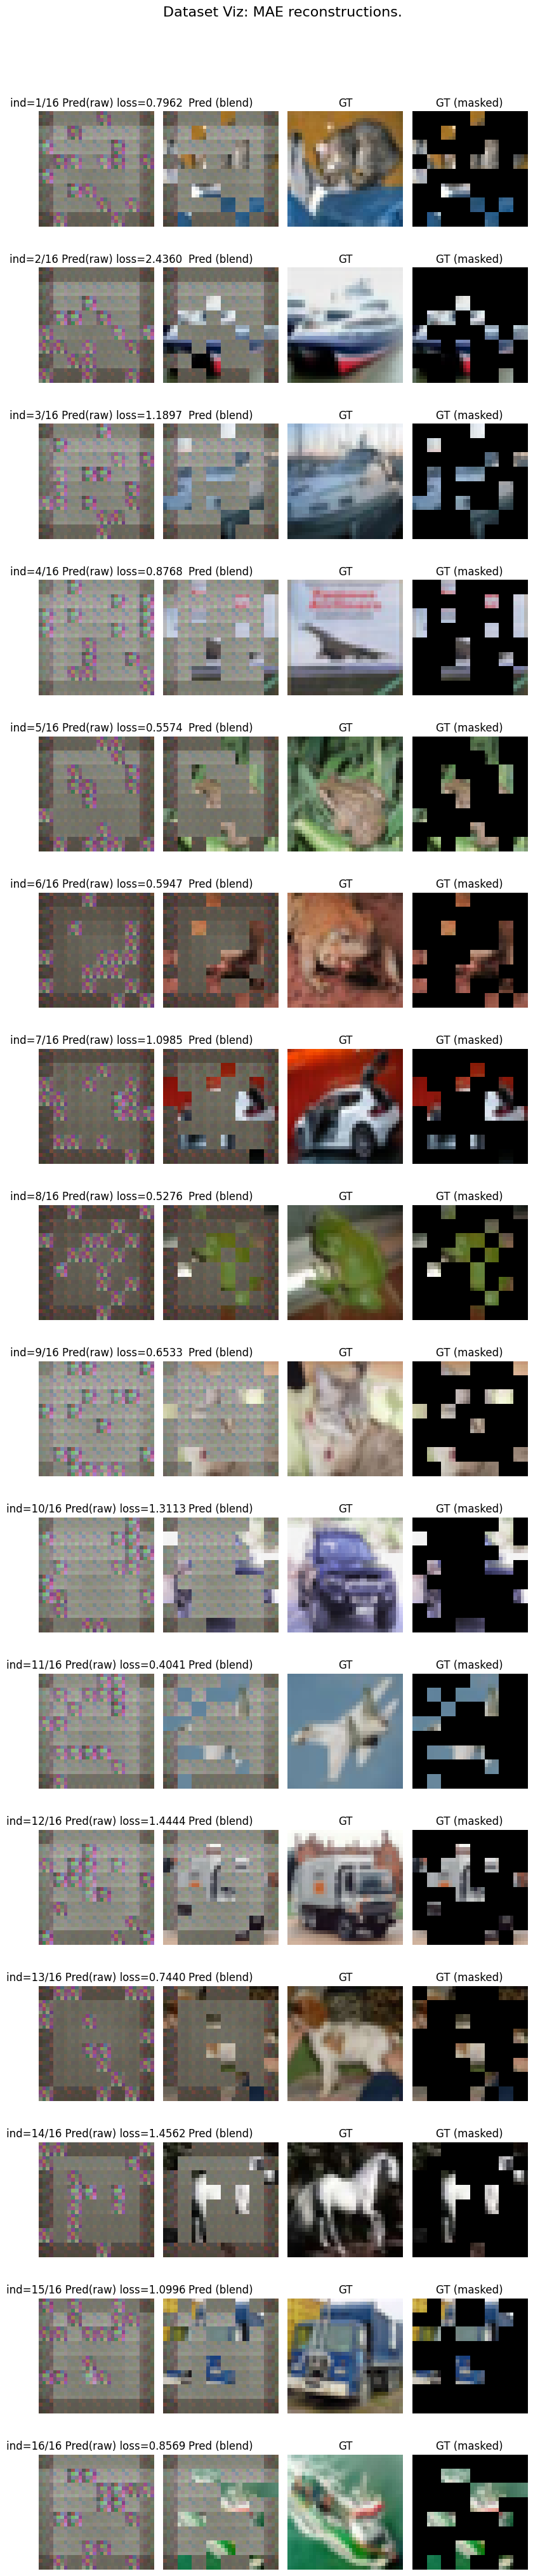

In [30]:
testset_viz_smallbatchsize = torchvision.datasets.CIFAR10(
    root=outdir_base_dataset, train=False, download=True, transform=transform_test
)
testloader_viz_smallbatchsize = torch.utils.data.DataLoader(
    testset_viz_smallbatchsize, batch_size=8, shuffle=False, num_workers=0
)


fig = visualize_mae_predictions(
    model=model,
    dataloader=testloader_viz_smallbatchsize,
    image_shape=CIFAR10_IMG_SHAPE,
    patchify=patchify,
    unpatchify=unpatchify,
    num_batches_viz=2,
    figsize=(8, 40),
    img_transform_fn=create_undo_img_standardization(CIFAR10_IMG_MEAN, CIFAR10_IMG_STD),
)


#### Visualize metrics (MAE)

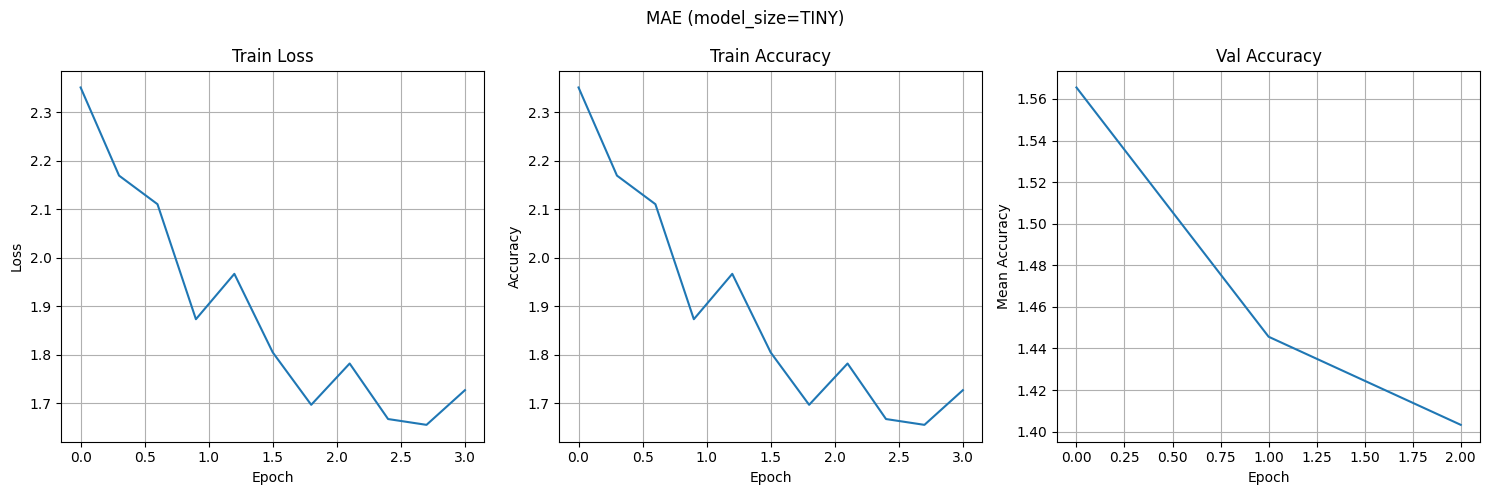

In [31]:
# Plotting
suptitle = f"MAE (model_size={MODEL_SIZE.name})"

fig = plot_train_val_metrics(
    train_meta=train_meta_mae_pretrain,
    val_meta=val_meta_mae_pretrain,
    suptitle=suptitle,
    # "accuracy" is actually pixel loss, so don't limit ylim
    acc_set_ylim_0_1=False,
)

fig.tight_layout()
fig.show()

### Use pretrained MAE model for classification

We train a shallow head to classify on top of the self-supervised representation learned by the MAE. It first processes the output from the MAE encoder by a multiheaded attention pooling, then layernorm, then linear.

In [32]:
class ClassificationMAE(nn.Module):
    """AttentionPooling-layernorm-linear classifier trained on the
    self-supervised representations learned by MAE.
    """

    def __init__(
        self,
        n_classes: int,
        mae: torch.nn.Module,
        embedding_dim: int = 256,
    ):
        """
        Args:
            n_classes: number of classes
            mae: mae model
            embedding_dim: embedding dimension of mae output
        """
        super().__init__()
        self.embedding_dim = embedding_dim
        self.mae = mae

        # Multiheaded Attention Pooling for classification
        self.cls_query = nn.Parameter(torch.randn(1, 1, embedding_dim))
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=embedding_dim, num_heads=4, batch_first=True
        )

        # A Layernorm and a Linear layer are applied on ViT encoder embeddings
        self.output_head = nn.Sequential(
            nn.LayerNorm(embedding_dim), nn.Linear(embedding_dim, n_classes)
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """
        Args:
            images: shape=[batch, channels, height, width]
        Returns:
            logits: shape=[batch, num_classes].
        """
        # BEGIN YOUR SOLUTION

        encoder_output = self.mae.forward_encoder_representation(images)

        batch_size = images.shape[0]
        cls_query_expand = self.cls_query.expand(batch_size, -1, -1)

        pooled_output, _ = self.cross_attention(
            query=cls_query_expand,
            key=encoder_output,
            value=encoder_output,
        )


        pooled_output = pooled_output.squeeze(1)

        logits = self.output_head(pooled_output)
        # END YOUR SOLUTION

        return logits


In [33]:
# Test your implementation
model = ClassificationMAE(
    10,
    MaskedAutoEncoder(
        Transformer(embedding_dim=256, n_layers=4),
        Transformer(embedding_dim=128, n_layers=2),
    ),
)

model.load_state_dict(test_data["weights"]["ClassificationMAE"])

check_error(
    "ClassificationMAE.forward",
    model(test_data["input"]["ClassificationMAE.forward"]),
    test_data["output"]["ClassificationMAE.forward"],
)

model = ClassificationMAE(
    10,
    MaskedAutoEncoder(
        Transformer(embedding_dim=256, n_layers=4),
        Transformer(embedding_dim=128, n_layers=2),
    ),
)

model.load_state_dict(auto_grader_data["weights"]["ClassificationMAE"])
student_data["output"]["ClassificationMAE.forward"] = model(
    auto_grader_data["input"]["ClassificationMAE.forward"]
)
save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)

The relative error for ClassificationMAE.forward is 2.1061437109892722e-06
Wrote student data (with keys=dict_keys(['output'])) to: /content/drive/MyDrive/data188/hw5/student_data.pt
keys in 'output': dict_keys(['patchify', 'unpatchify', 'ClassificationViT.forward', 'vit_acc', 'random_masking', 'restore_masked', 'MaskedAutoEncoder.forward_encoder', 'MaskedAutoEncoder.forward_decoder', 'MaskedAutoEncoder.forward_encoder_representation', 'ClassificationMAE.forward'])


### [train] (V2) Linear Probing

A linear classifier is trained on self-supervised representations learned by MAE, where we freeze all layers except for the linear classifier.

You should get results similar to the following:

| Model Size       | Model Parameters | Train Loss | Train Accuracy | Val Accuracy | Per-epoch secs (CPU)* | Per-epoch secs (GPU)** |
| ---------------- | ---------------- | ---------- | -------------- | ------------ | -------------------- | -------------------- |
| TINY (3 epochs)  | 1386 (142 unfrozen) | 2.15  | 0.2    | 0.2  | 28                   | TODO                 |
| FULL (20 epochs) | 4161594 (266506 unfrozen) | 0.9 - 1.1       | 0.6 - 0.7           | 0.62 - 0.65 | >540                 | 27                   |

\* As measured on the default Google Colab CPU instance.

\** As measured on a Google Colab T4 GPU instance.

Note: With an Nvidia RTX 3080 GPU, I got 7 secs per epoch for model_size=FULL.

**Tip**: once you've successfully trained the model, it will be saved to disk at `./data/model_snapshots/`.
When you re-run this cell, this will load the model snapshot from disk, rather than training a new model, which will save you some time if you need to resume work on this notebook.

If you wish to retrain a model, either delete the model snapshot from disk, or set `force_retrain = True` in `train_loop()`.

In [34]:
# GPU(full): 10 mins (30 secs per epoch)
# CPU(full): >3 hours
# CPU(tiny): 13 mins (40 secs per epoch)
# IMPORTANT: `mae` must be kept in sync with the model arch used to generate "mae_pretrained.pth"
#   If you get an error like this:
#       Error(s) in loading state_dict for MaskedAutoEncoder: Missing key(s) in state_dict
#   Then this means there is a mismatch between your `mae` definition and what
#   is saved in "mae_pretrained.pth".
#   Worst case: if you don't remember the settings, you can re-run the "Train Masked Autoencoder",
#     then copy+paste the model definition from that cell to here
print(f"Creating MaskedAutoEncoder with MODEL_SIZE={MODEL_SIZE}")
if MODEL_SIZE == ModelSize.FULL:
    encoder_embedding_dim = 256
    mae = MaskedAutoEncoder(
        Transformer(embedding_dim=encoder_embedding_dim, n_layers=4),
        Transformer(embedding_dim=128, n_layers=2),
        patch_size=4,
        num_patches=8,
        mask_ratio=0.75,
        channels=CIFAR10_IMG_SHAPE[0],
    )
else:
    # TINY
    encoder_embedding_dim = 4
    mae = MaskedAutoEncoder(
        Transformer(embedding_dim=encoder_embedding_dim, n_layers=1, feedforward_dim=4),
        Transformer(embedding_dim=4, n_layers=1, feedforward_dim=4),
        encoder_embedding_dim=encoder_embedding_dim,
        decoder_embedding_dim=4,
        patch_size=4,
        num_patches=8,
        mask_ratio=0.75,
        channels=CIFAR10_IMG_SHAPE[0],
    )

# Load best MAE snapshot
mae.load_state_dict(
    torch.load(outpath_mae_pretrained_best, weights_only=True)["weights"]
)

model = ClassificationMAE(10, mae, embedding_dim=encoder_embedding_dim)
for param in model.mae.parameters():
    param.requires_grad = False
model = model.to(torch_device)

if torch_compile_mode is not None:
    model = torch.compile(model, mode=torch_compile_mode)

print(f"Num model parameters (unfrozen): {count_model_parameters(model)}")
print(
    f"Num model parameters (frozen+unfrozen): {count_model_parameters(model, only_trainable=False)}"
)

# Tip: with a correct implementation (and "full" model size), you should be able to pass
#   the autograder tests with these provided hyperparameter values.
optimizer = optim.AdamW(
    [param for param in model.parameters() if param.requires_grad],
    lr=3e-4,
    betas=(0.9, 0.95),
    weight_decay=1e-2,
    eps=1e-9,
)
if use_amp:
    grad_scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
else:
    grad_scaler = None

if torch_device == "cpu":
    # CPU is only for small-scale testing, no need to train many epochs
    num_epochs = 3
else:
    # GPU: full epoch train schedule
    num_epochs = 20

outpath_vit_mae_cls_best = os.path.join(
    outdir_base_models, f"v2_vit_mae_cls_best_{MODEL_SIZE.value}.pth"
)
outpath_vit_mae_cls_best_meta = f"{outpath_vit_mae_cls_best}.meta"

train_meta_v2, val_meta_v2 = load_if_exists_else_train(
    model=model,
    optimizer=optimizer,
    dataloader_train=trainloader,
    dataloader_val=testloader,
    num_epochs=num_epochs,
    outpath_best_val=outpath_vit_mae_cls_best,
    outpath_best_val_meta=outpath_vit_mae_cls_best_meta,
    is_jupyter_notebook=True,
    # set force_retrain to True to retrain model even if it already exists on disk
    force_retrain=False,
    use_amp=use_amp,
    grad_scaler=grad_scaler,
)

Creating MaskedAutoEncoder with MODEL_SIZE=ModelSize.TINY
Num model parameters (unfrozen): 142
Num model parameters (frozen+unfrozen): 1386


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=1/3] (Train) dur=26.97s. tput=1853.97 exs/s (Val) dur=4.56s tput=2191.83 exs/s. val_acc=0.148932 (best_val_acc=0.000000)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v2_vit_mae_cls_best_tiny.pth (val_acc=0.148932 vs prev_best_val_acc=0.148932) (flip_val_acc_cmp=False)


  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=2/3] (Train) dur=27.61s. tput=1810.66 exs/s (Val) dur=4.48s tput=2231.66 exs/s. val_acc=0.163667 (best_val_acc=0.148932)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v2_vit_mae_cls_best_tiny.pth (val_acc=0.163667 vs prev_best_val_acc=0.163667) (flip_val_acc_cmp=False)


  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=3/3] (Train) dur=26.13s. tput=1913.27 exs/s (Val) dur=5.01s tput=1995.75 exs/s. val_acc=0.171875 (best_val_acc=0.163667)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v2_vit_mae_cls_best_tiny.pth (val_acc=0.171875 vs prev_best_val_acc=0.171875) (flip_val_acc_cmp=False)
Training complete. 94.87 secs. best_val_acc=0.171875
Saved train/val meta to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v2_vit_mae_cls_best_tiny.pth.meta


#### Visualize predictions (V2)

Running inference on 10000 samples...
Finished inference on 10000 samples (3.27 secs, throughput=3055.12 samples/sec)
uhoh, not enough, skipping: (0, 32, 32, 3), 0


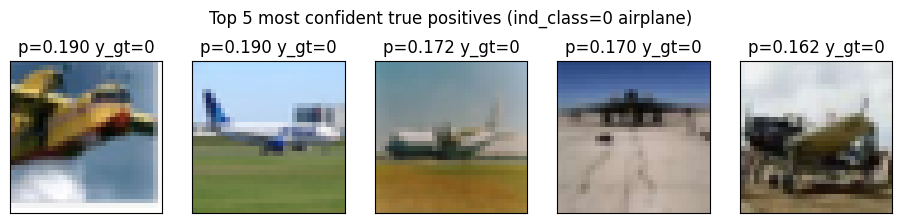

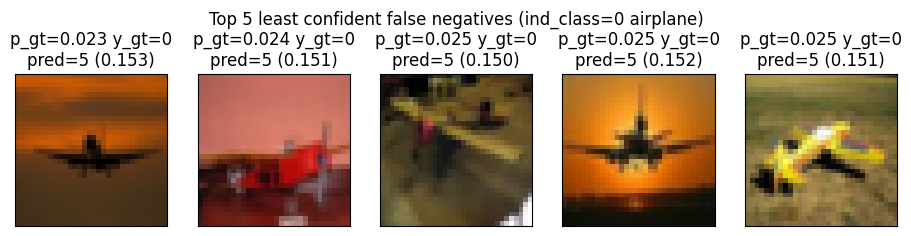

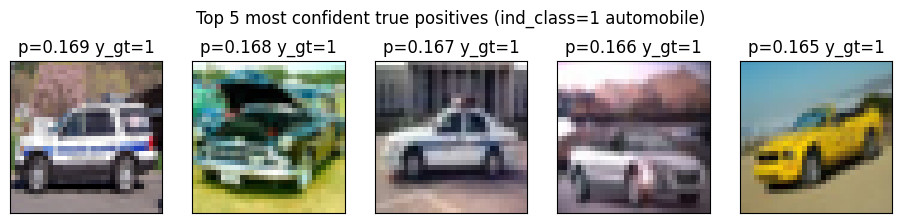

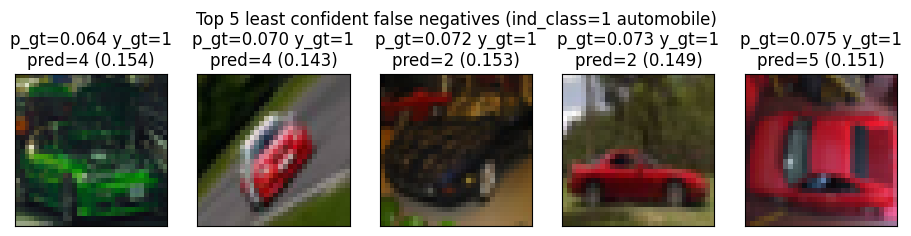

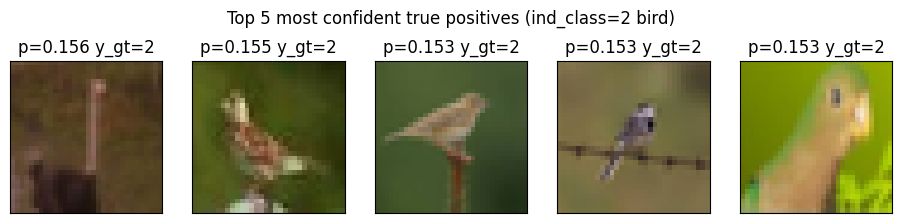

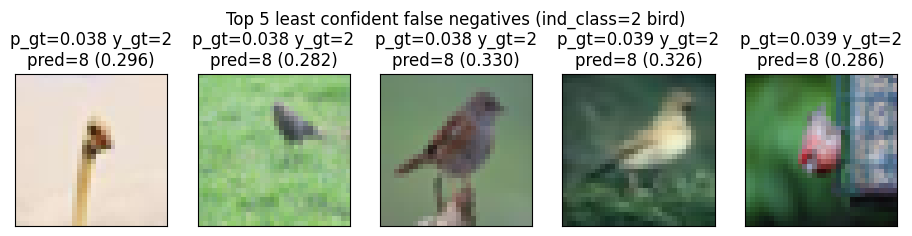

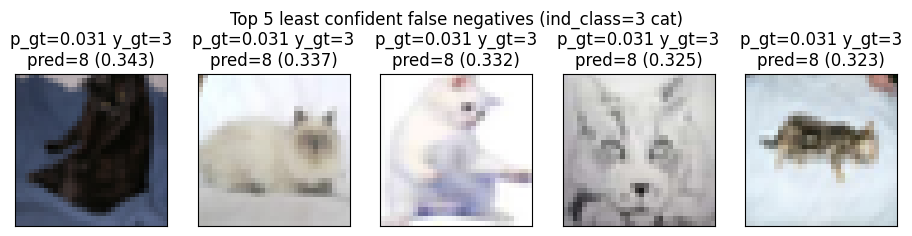

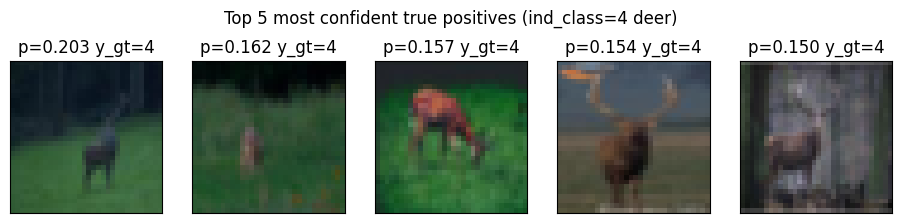

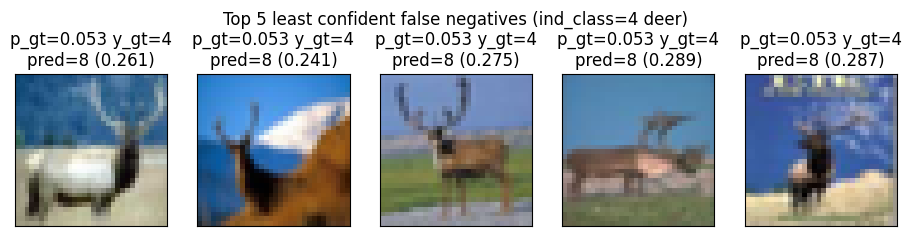

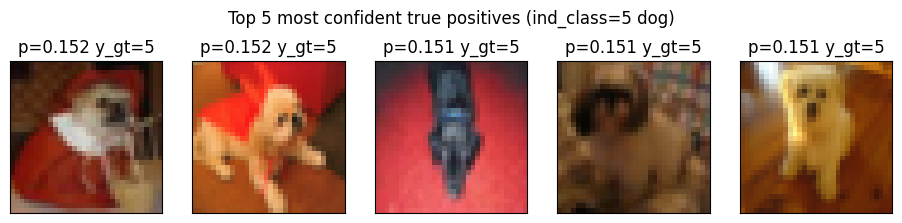

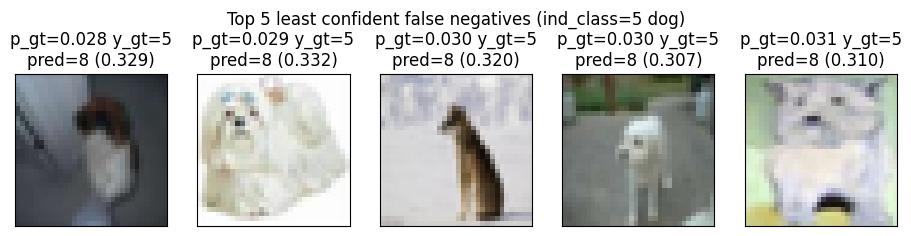

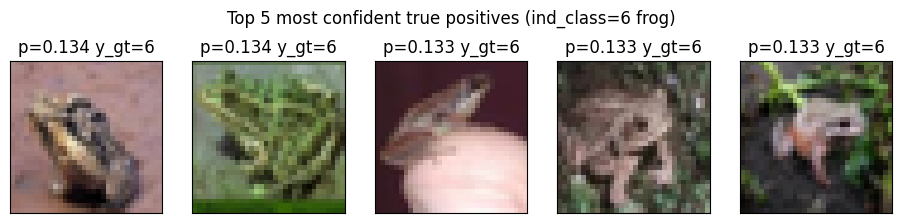

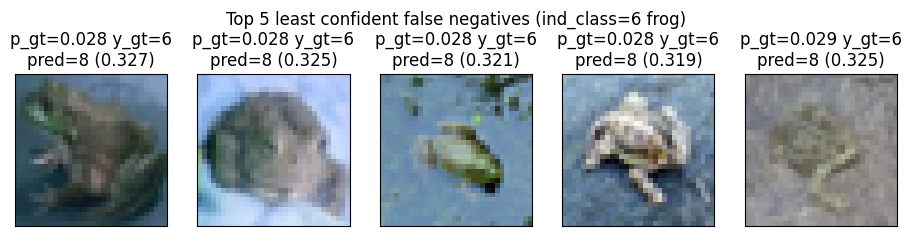

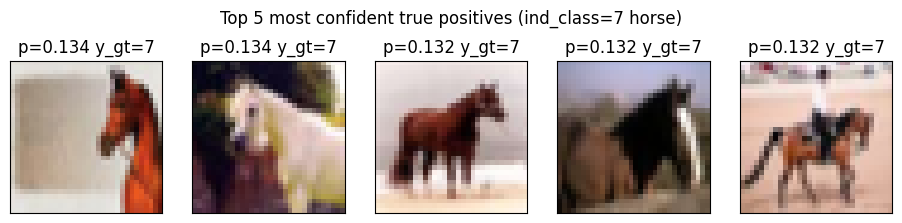

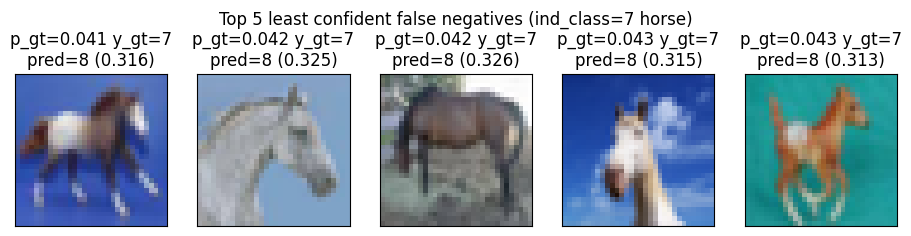

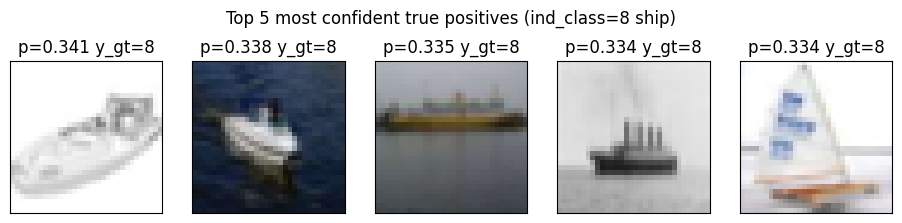

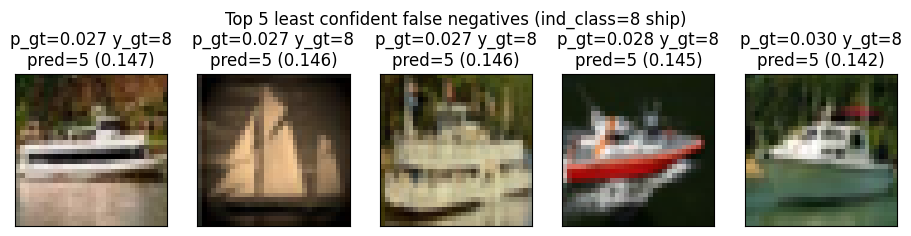

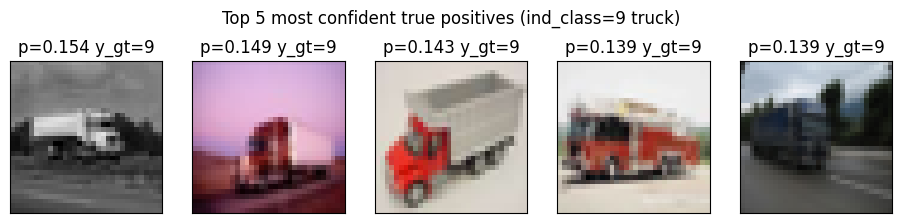

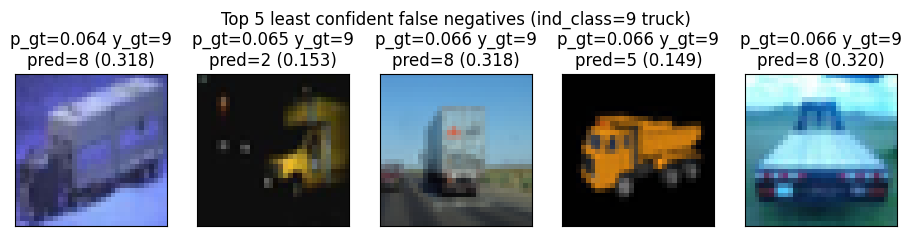

In [35]:
visualize_image_classifier_preds(
    model=model,
    dataloader=testloader,
    class_names=testloader.dataset.classes,
    image_shape=(3, 32, 32),
    top_k=5,
    dataloader_viz=testloader_viz,
)

#### Visualize metrics (V2)

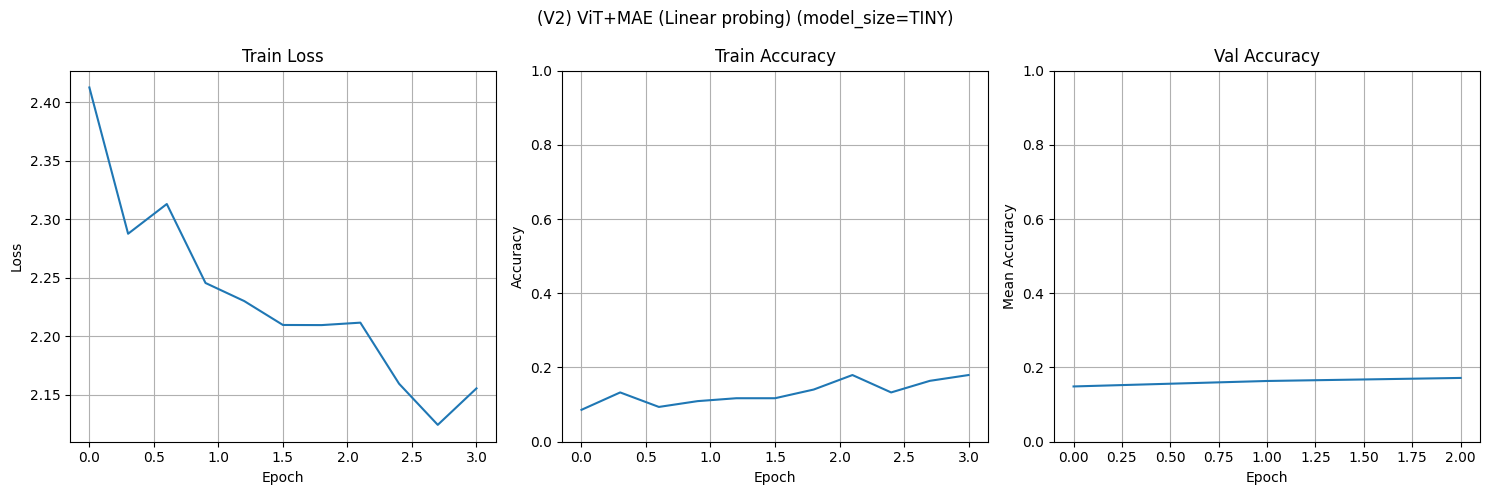

In [36]:
# Plotting
suptitle = f"(V2) ViT+MAE (Linear probing) (model_size={MODEL_SIZE.name})"

fig = plot_train_val_metrics(
    train_meta=train_meta_v2,
    val_meta=val_meta_v2,
    suptitle=suptitle,
)

fig.tight_layout()
fig.show()

In [37]:
# Your val accuracy should be greater than 45%
best_val_acc = np.max(val_meta_v2["accuracy_per_epoch"])
student_data["output"]["mae_linear_acc"] = best_val_acc
save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)
check_acc(best_val_acc, threshold=0.45)

Wrote student data (with keys=dict_keys(['output'])) to: /content/drive/MyDrive/data188/hw5/student_data.pt
keys in 'output': dict_keys(['patchify', 'unpatchify', 'ClassificationViT.forward', 'vit_acc', 'random_masking', 'restore_masked', 'MaskedAutoEncoder.forward_encoder', 'MaskedAutoEncoder.forward_decoder', 'MaskedAutoEncoder.forward_encoder_representation', 'ClassificationMAE.forward', 'mae_linear_acc'])
The accuracy 0.171875 should >= threshold accuracy 0.45


### [train] (V3) Full Finetuning

A linear classifer and the pretrained MAE model are jointly updated.

You should get results similar to the following:

| Model Size | Model Parameters | Train Loss | Train Accuracy | Val Accuracy | Per-epoch secs (CPU)* | Per-epoch secs (GPU)** |
| ---------- | ---------------- | ---------- | -------------- | ------------ | -------------------- | -------------------- |
| TINY (3 epochs)  | 1386 | 2.05  | 0.21    | 0.21  | 32                   | TODO                 |
| FULL (20 epochs) | 4161594 | 0.3 - 0.4       | 0.8 - 0.9           | 0.79 - 0.82 | >540                 | 30                   |

\* As measured on the default Google Colab CPU instance.

\** As measured on a Google Colab T4 GPU instance.

Note: With an Nvidia RTX 3080 GPU, I got 7 secs per epoch for model_size=FULL.

**Tip**: once you've successfully trained the model, it will be saved to disk at `./data/model_snapshots/`.
When you re-run this cell, this will load the model snapshot from disk, rather than training a new model, which will save you some time if you need to resume work on this notebook.

If you wish to retrain a model, either delete the model snapshot from disk, or set `force_retrain = True` in `train_loop()`.

In [38]:
# GPU(T4): 11 mins (33 secs per epoch)
# CPU: >3 hours
# CPU(tiny): 18 mins (50 secs per epoch)

# IMPORTANT: `mae` must be kept in sync with the model arch used to generate "mae_pretrained.pth"
print(f"Creating MaskedAutoEncoder with MODEL_SIZE={MODEL_SIZE}")
if MODEL_SIZE == ModelSize.FULL:
    encoder_embedding_dim = 256
    mae = MaskedAutoEncoder(
        Transformer(embedding_dim=encoder_embedding_dim, n_layers=4),
        Transformer(embedding_dim=128, n_layers=2),
        patch_size=4,
        num_patches=8,
        mask_ratio=0.75,
        channels=CIFAR10_IMG_SHAPE[0],
    )
else:
    # TINY
    encoder_embedding_dim = 4
    mae = MaskedAutoEncoder(
        Transformer(embedding_dim=encoder_embedding_dim, n_layers=1, feedforward_dim=4),
        Transformer(embedding_dim=4, n_layers=1, feedforward_dim=4),
        encoder_embedding_dim=encoder_embedding_dim,
        decoder_embedding_dim=4,
        patch_size=4,
        num_patches=8,
        mask_ratio=0.75,
        channels=CIFAR10_IMG_SHAPE[0],
    )

mae.load_state_dict(
    torch.load(outpath_mae_pretrained_best, weights_only=True)["weights"]
)
model = ClassificationMAE(10, mae, embedding_dim=encoder_embedding_dim)
model = model.to(device=torch_device)
if torch_compile_mode is not None:
    model = torch.compile(model, mode=torch_compile_mode)

print(f"Num model parameters (unfrozen): {count_model_parameters(model)}")
print(
    f"Num model parameters (frozen+unfrozen): {count_model_parameters(model, only_trainable=False)}"
)

# Tip: with a correct implementation (and "full" model size), you should be able to pass
#   the autograder tests with these provided hyperparameter values.
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    betas=(0.9, 0.95),
    weight_decay=1e-2,
    eps=1e-9,
)
if use_amp:
    grad_scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
else:
    grad_scaler = None

if torch_device == "cpu":
    # CPU is only for small-scale testing, no need to train many epochs
    num_epochs = 3
else:
    # GPU: full epoch train schedule
    num_epochs = 20

outpath_vit_mae_joint_best = os.path.join(
    outdir_base_models, f"v3_vit_mae_cls_joint_best_{MODEL_SIZE.value}.pth"
)
outpath_vit_mae_joint_best_meta = f"{outpath_vit_mae_joint_best}.meta"

train_meta_v3, val_meta_v3 = load_if_exists_else_train(
    model=model,
    optimizer=optimizer,
    dataloader_train=trainloader,
    dataloader_val=testloader,
    num_epochs=num_epochs,
    outpath_best_val=outpath_vit_mae_joint_best,
    outpath_best_val_meta=outpath_vit_mae_joint_best_meta,
    is_jupyter_notebook=True,
    # set force_retrain to True to retrain model even if it already exists on disk
    force_retrain=False,
    use_amp=use_amp,
    grad_scaler=grad_scaler,
)

Creating MaskedAutoEncoder with MODEL_SIZE=ModelSize.TINY
Num model parameters (unfrozen): 1386
Num model parameters (frozen+unfrozen): 1386


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=1/3] (Train) dur=32.66s. tput=1530.73 exs/s (Val) dur=5.36s tput=1866.22 exs/s. val_acc=0.136867 (best_val_acc=0.000000)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v3_vit_mae_cls_joint_best_tiny.pth (val_acc=0.136867 vs prev_best_val_acc=0.136867) (flip_val_acc_cmp=False)


  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=2/3] (Train) dur=32.79s. tput=1524.87 exs/s (Val) dur=3.15s tput=3174.53 exs/s. val_acc=0.170293 (best_val_acc=0.136867)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v3_vit_mae_cls_joint_best_tiny.pth (val_acc=0.170293 vs prev_best_val_acc=0.170293) (flip_val_acc_cmp=False)


  0%|          | 0/390 [00:00<?, ?it/s]

[epoch=3/3] (Train) dur=32.86s. tput=1521.38 exs/s (Val) dur=3.15s tput=3169.60 exs/s. val_acc=0.218157 (best_val_acc=0.170293)
Saved best val model to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v3_vit_mae_cls_joint_best_tiny.pth (val_acc=0.218157 vs prev_best_val_acc=0.218157) (flip_val_acc_cmp=False)
Training complete. 110.09 secs. best_val_acc=0.218157
Saved train/val meta to: /content/drive/MyDrive/data188/hw5/./data/model_snapshots/v3_vit_mae_cls_joint_best_tiny.pth.meta


#### Visualize predictions (V3)

Running inference on 10000 samples...
Finished inference on 10000 samples (3.21 secs, throughput=3113.59 samples/sec)
uhoh, not enough, skipping: (4, 32, 32, 3), 4
uhoh, not enough, skipping: (0, 32, 32, 3), 0


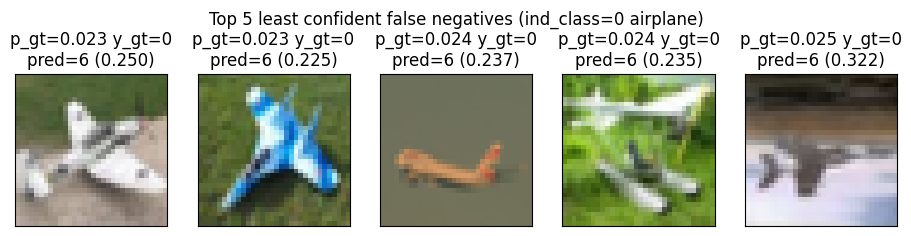

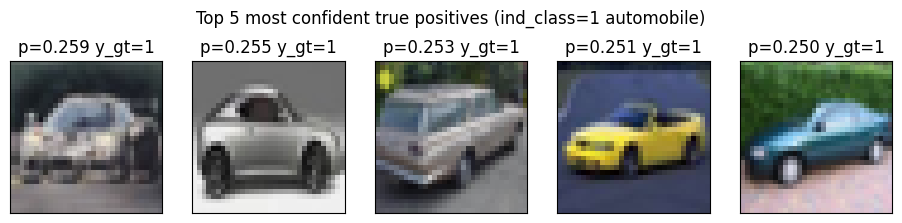

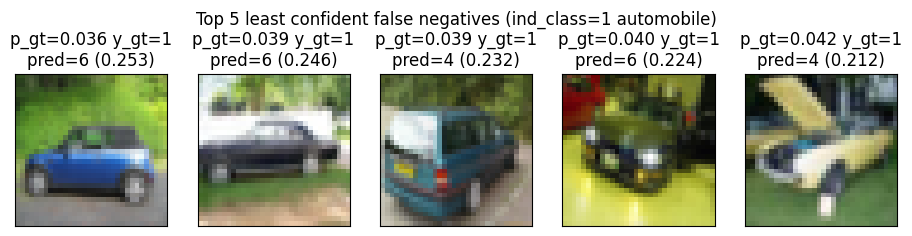

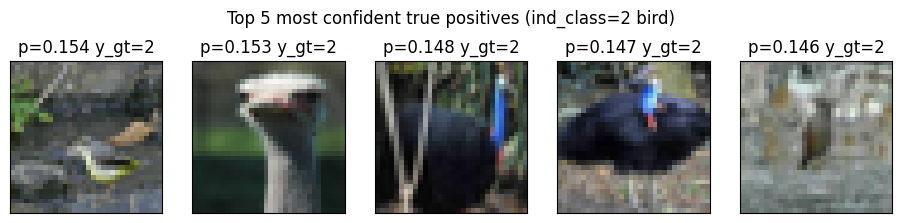

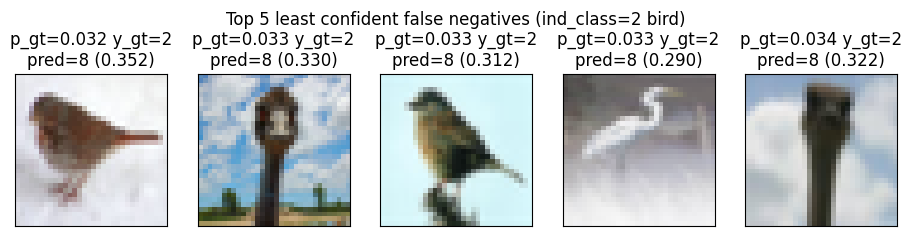

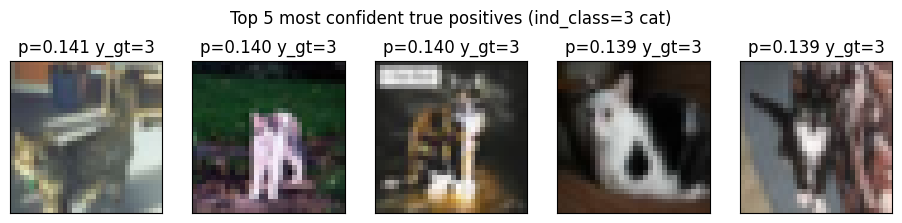

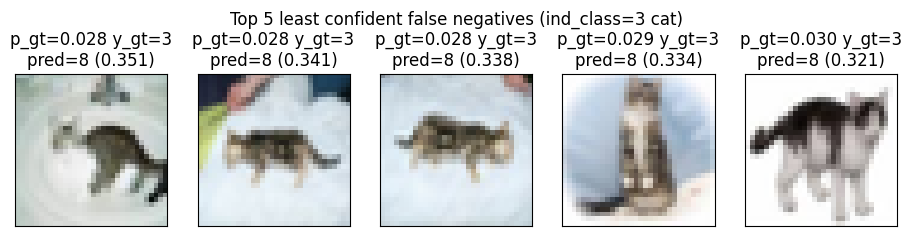

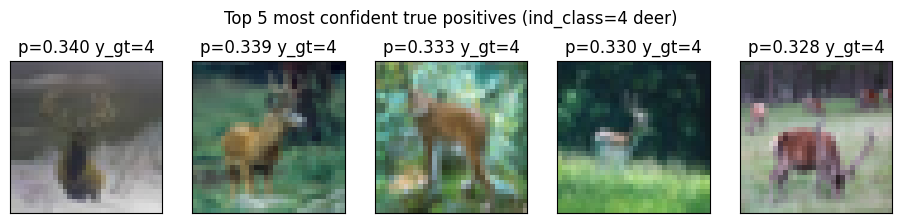

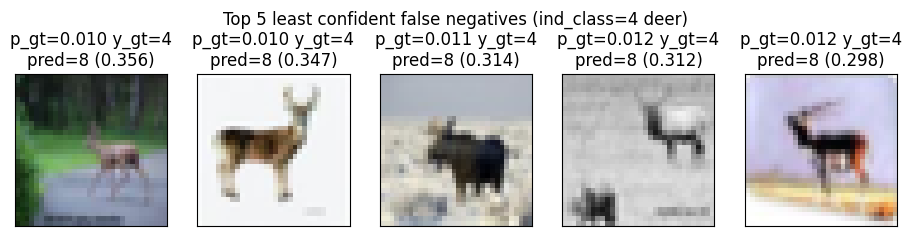

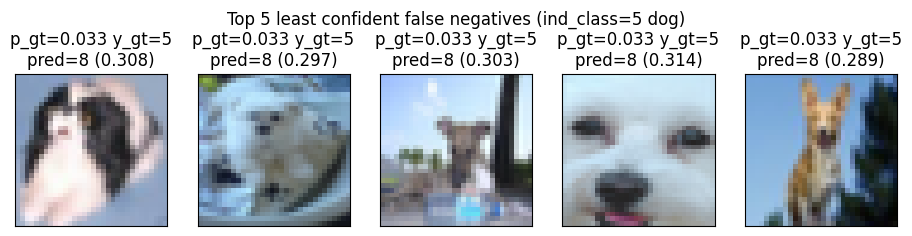

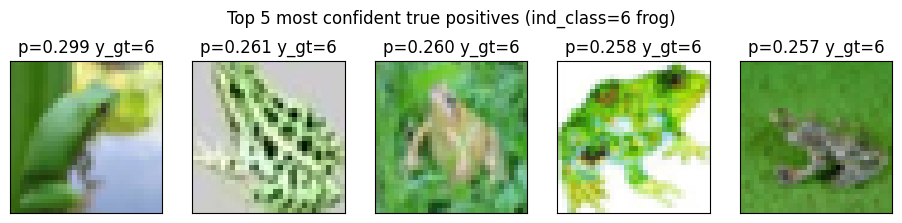

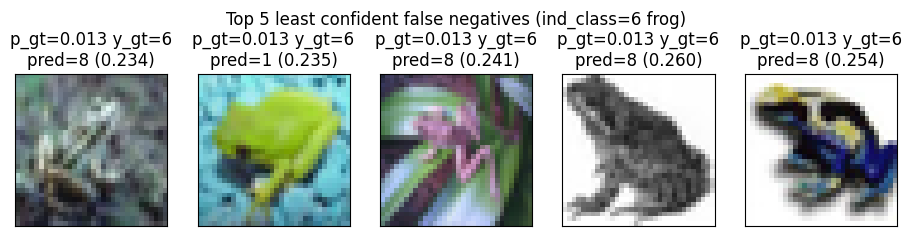

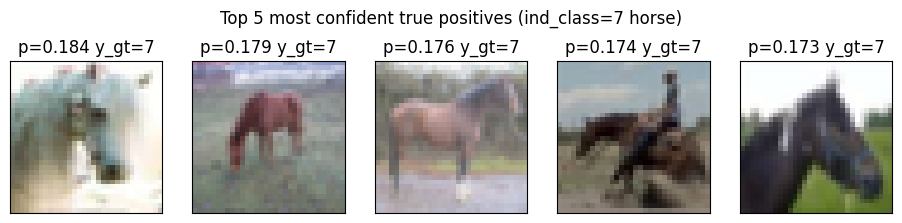

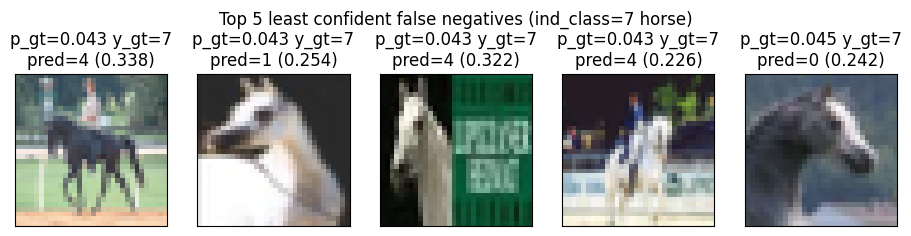

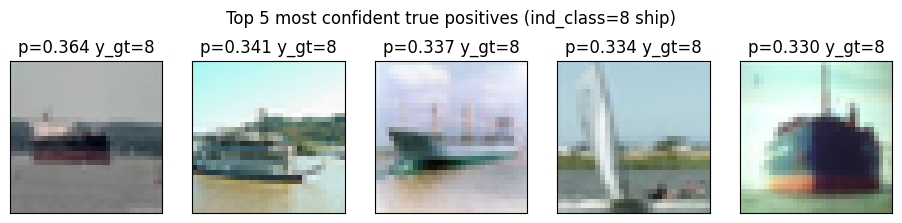

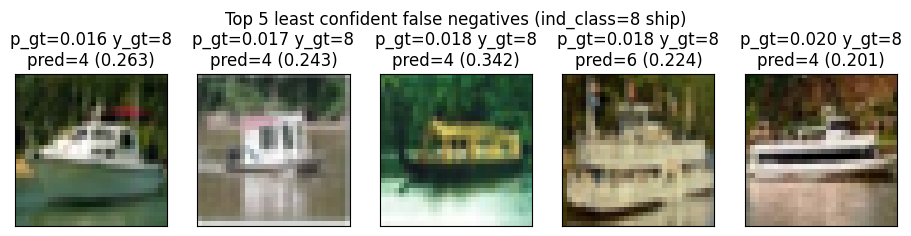

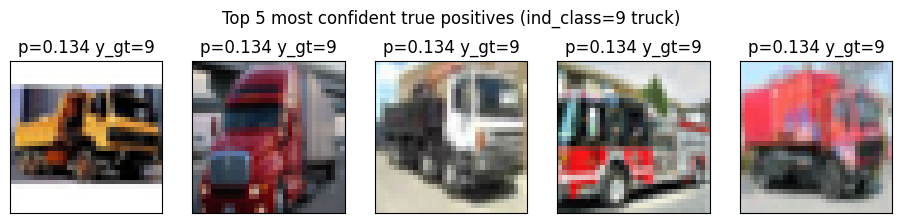

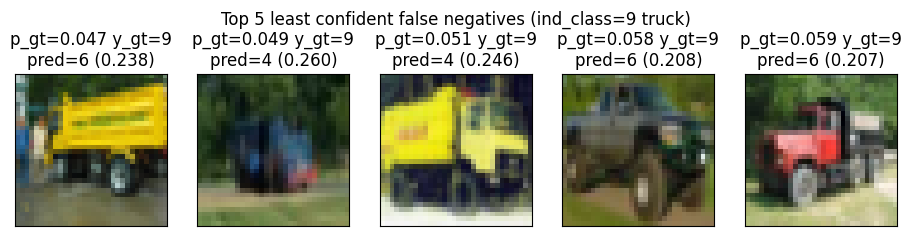

In [39]:
visualize_image_classifier_preds(
    model=model,
    dataloader=testloader,
    class_names=testloader.dataset.classes,
    image_shape=(3, 32, 32),
    top_k=5,
    dataloader_viz=testloader_viz,
)

#### Visualize metrics (V3)

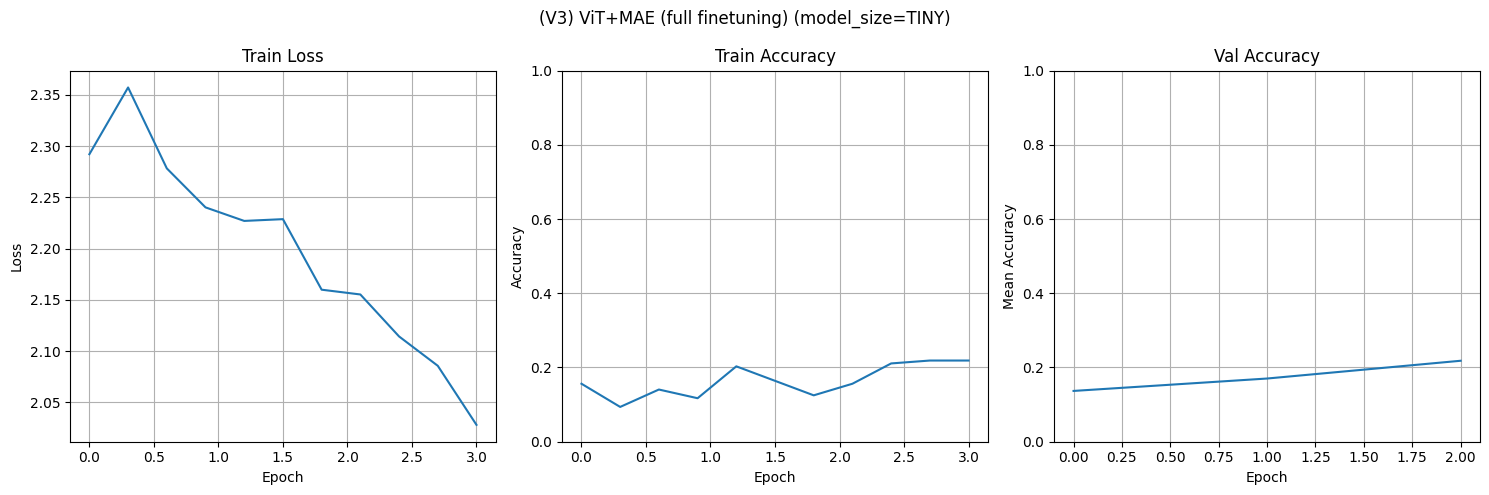

In [40]:
# Plotting
suptitle = f"(V3) ViT+MAE (full finetuning) (model_size={MODEL_SIZE.name})"

fig = plot_train_val_metrics(
    train_meta=train_meta_v3,
    val_meta=val_meta_v3,
    suptitle=suptitle,
)

fig.tight_layout()
fig.show()

In [41]:
# Your validation accuracy should be greater than 70%
best_val_acc = np.max(val_meta_v3["accuracy_per_epoch"])
student_data["output"]["mae_finetune_acc"] = best_val_acc
save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)
check_acc(best_val_acc, threshold=0.70)

Wrote student data (with keys=dict_keys(['output'])) to: /content/drive/MyDrive/data188/hw5/student_data.pt
keys in 'output': dict_keys(['patchify', 'unpatchify', 'ClassificationViT.forward', 'vit_acc', 'random_masking', 'restore_masked', 'MaskedAutoEncoder.forward_encoder', 'MaskedAutoEncoder.forward_decoder', 'MaskedAutoEncoder.forward_encoder_representation', 'ClassificationMAE.forward', 'mae_linear_acc', 'mae_finetune_acc'])
The accuracy 0.21815664556962025 should >= threshold accuracy 0.7


\## Compare V1, V2, V3

Let's generate a plot comparing V1, V2, and V3 training methodologies.

You should see the following trend for validation accuracy: at the end of training, V3 > V1 > V2.

Notably, at the beginning of training (ie early epochs 1-2), V3 should outperform V1 by a noticeable margin.
Why do you think this is?

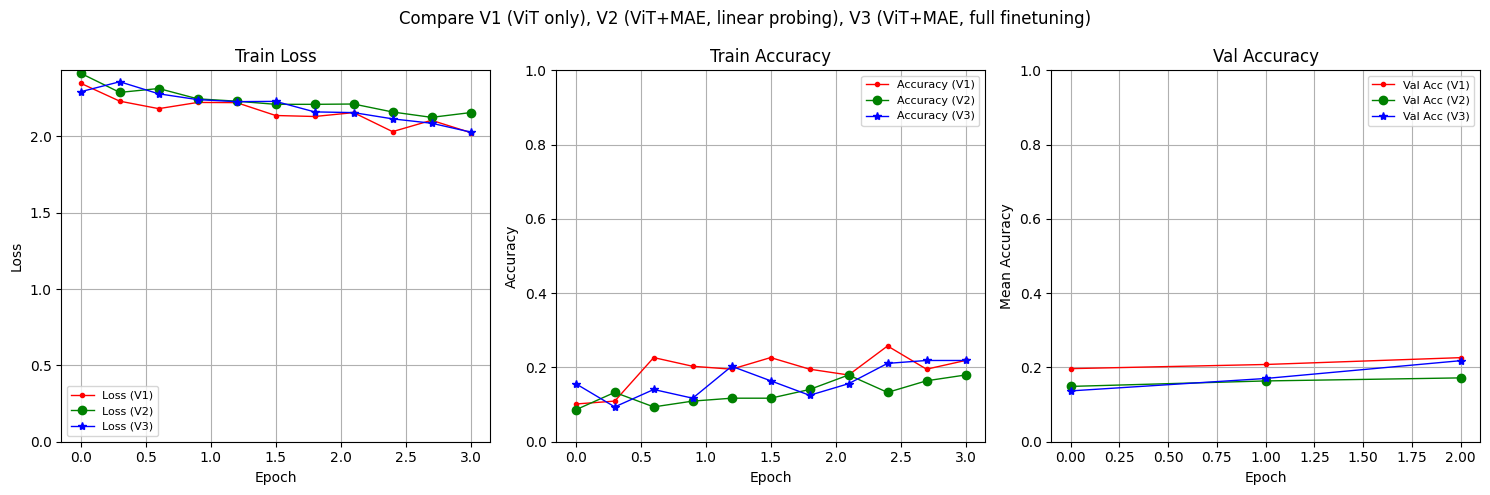

In [42]:
fig_cmp = plot_train_val_metrics_cmp(
    train_meta=train_meta,
    val_meta=val_meta,
    train_meta_v2=train_meta_v2,
    val_meta_v2=val_meta_v2,
    train_meta_v3=train_meta_v3,
    val_meta_v3=val_meta_v3,
    suptitle="Compare V1 (ViT only), V2 (ViT+MAE, linear probing), V3 (ViT+MAE, full finetuning)",
)

fig_cmp.tight_layout()
fig_cmp.show()

# Homework Submission

These cells package your homework outputs for submission.

To submit your homework assignment, we will do two things:
- (1) Package your code (and any relevant produced artifacts like model weights, `.pth` files, `.pt` files, etc) into a submission zip file
- (2) Download your submission zip file to your local machine
- (3) (your action required) Upload the submission zip file to Gradescope

Once you've submitted to Gradescope, the Gradescope autograder will run and assign your earned points.

**Important**: before you run the below cells, please save your notebook to ensure that your submission zip contains your latest notebook (ie code and generated outputs/figures).

Run the below cells to prepare+download your submission zip file:

In [ ]:
# Save the dictionaries
save_student_data(student_data=student_data, outpath_student_data=OUTPATH_STUDENT_DATA)

In [ ]:
# Packages code+artifacts into zip file, and download it to your local machine
# Tip: the zip file will be downloaded to your browser's default download folder, eg `~/Downloads, C:\Users\YourUserName\Downloads`, etc.
# IMPORTANT: be sure that `rootdir_asn` is defined correctly in previous cell
from utils_public.utils import run_cmd

os.chdir(rootdir_asn)
print("cwd: ", os.getcwd())  # make sure we are in the right dir
print("ls cwd: ", os.listdir(os.getcwd()))

zip_outpath = f"{asn_name}_submission.zip"
print(f"Creating zip file (zip_outpath={zip_outpath})...")
run_cmd(["bash", "./utils_public/prepare_submission.sh", zip_outpath])
print("Created zipfile!")

# Check if filesize is too big
filesize_mb = os.path.getsize(zip_outpath) / (1024 * 1024)
print(f"Zip file size: {filesize_mb} MB")
if filesize_mb > 20:
    print(
        f"Warning: your submission zip is very large, and may result in autograder issues. Please investigate, perhaps you accidentally included unnecessary files?"
    )

# Download created zipfile to your local machine
from google.colab import files

files.download(zip_outpath)
print(
    f"Finished downloading {zip_outpath}! Upload this zip file to Gradescope as your submission to run the autograder. "
    "\nThe zip file will be in your browser's default download directory, eg '~/Downloads', 'C:\\Users\\YourUserName\\Downloads', etc"
)